# Sales Analysis Report - AAL (Australian Apparel Limited)
## Q4 2020 Sales Data Analysis

**Project Overview:**
AAL (Australian Apparel Limited), established in 2000, is analyzing their Q4 2020 sales data to:
1. Identify states generating the highest revenues
2. Develop sales programs for states with lower revenues
3. Make data-driven decisions for the upcoming year

**Data Source:** AusApparalSales4thQrt2020.csv

**Analysis Structure:**
1. Data Wrangling
2. Data Analysis
3. Data Visualization
4. Report Generation

---

## 📚 Universal EDA Framework (For Any Problem)

**Exploratory Data Analysis (EDA) is the foundation of data science. The following framework can be applied to ANY dataset:**

### Phase 1: Data Understanding & Quality Assessment
1. **Load and Inspect Data**
   - Shape, size, columns
   - Data types
   - First/last few rows
   - Sample data

2. **Data Quality Checks**
   - Missing values (isna(), notna())
   - Duplicates
   - Data types consistency
   - Invalid/incorrect entries
   - Data range validation

### Phase 2: Data Cleaning & Preprocessing
3. **Handle Missing Values**
   - Identify patterns
   - Decide: drop vs fill
   - Choose imputation method

4. **Handle Outliers**
   - Detect outliers (IQR, Z-score, visual)
   - Understand why they exist
   - Decide: remove vs transform vs keep

5. **Data Transformation**
   - Normalization/Standardization
   - Encoding categorical variables
   - Feature engineering
   - Date/time parsing

### Phase 3: Univariate Analysis (Single Variable)
6. **Numerical Variables**
   - Descriptive statistics (mean, median, mode, std, min, max)
   - Distribution analysis (histograms, KDE plots)
   - Skewness and Kurtosis
   - Box plots (outlier detection)

7. **Categorical Variables**
   - Value counts
   - Frequency distributions
   - Bar charts
   - Mode identification

### Phase 4: Bivariate Analysis (Two Variables)
8. **Numerical vs Numerical**
   - Scatter plots
   - Correlation analysis
   - Correlation heatmaps
   - Regression plots

9. **Categorical vs Numerical**
   - Group comparisons (box plots, violin plots)
   - Group statistics (mean, median by category)
   - ANOVA (if applicable)

10. **Categorical vs Categorical**
    - Contingency tables
    - Chi-square tests
    - Stacked bar charts
    - Heatmaps

### Phase 5: Multivariate Analysis (Multiple Variables)
11. **Advanced Visualizations**
    - Pair plots
    - Correlation matrices
    - Multi-dimensional analysis
    - Principal Component Analysis (if needed)

### Phase 6: Time Series Analysis (If Applicable)
12. **Temporal Patterns**
    - Trends over time
    - Seasonality
    - Cyclical patterns
    - Time-based aggregations

### Phase 7: Insights & Recommendations
13. **Key Findings**
    - Summarize patterns
    - Identify relationships
    - Highlight anomalies

14. **Actionable Insights**
    - Business recommendations
    - Next steps
    - Further analysis suggestions

---

**Note:** Not all steps are needed for every problem. Adapt based on:
- Data type (numerical, categorical, time series)
- Problem type (classification, regression, clustering)
- Business objectives
- Data size and complexity


## Step 1: Import Required Libraries

**Explanation:** 
We need to import essential libraries for data manipulation, analysis, and visualization:
- **pandas**: For data manipulation and analysis
- **numpy**: For numerical operations
- **matplotlib**: For basic plotting
- **seaborn**: For statistical visualizations (preferred for this analysis)
- **warnings**: To suppress unnecessary warnings
- **datetime**: For date manipulation

In [17]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

# Set style for seaborn plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
Pandas version: 3.0.0
NumPy version: 2.4.2
Seaborn version: 0.13.2


## Step 2: Data Wrangling

### 2.1 Loading the Data

**Explanation:**
The first step in any data analysis is to load the data into a pandas DataFrame. This allows us to:
- View the structure of the data
- Understand the columns and data types
- Get a sense of the data size

In [18]:
# Load the CSV file
df = pd.read_csv('AusApparalSales4thQrt2020.csv')

# Display basic information about the dataset
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape of the dataset: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("FIRST 10 ROWS OF THE DATASET")
print("=" * 60)
df.head(10)

DATASET OVERVIEW

Shape of the dataset: (7560, 6)
Number of rows: 7560
Number of columns: 6

COLUMN NAMES AND DATA TYPES
Date       str
Time       str
State      str
Group      str
Unit     int64
Sales    int64
dtype: object

FIRST 10 ROWS OF THE DATASET


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500
5,1-Oct-2020,Afternoon,WA,Men,10,25000
6,1-Oct-2020,Afternoon,WA,Women,3,7500
7,1-Oct-2020,Afternoon,WA,Seniors,11,27500
8,1-Oct-2020,Evening,WA,Kids,15,37500
9,1-Oct-2020,Evening,WA,Men,15,37500


### 2.2 Data Cleaning - Checking for Missing Values

**Explanation:**
Data cleaning is crucial because:
- Missing values can skew our analysis
- Incorrect entries can lead to wrong conclusions
- We use `isna()` and `notna()` functions to identify missing values

**isna()**: Returns True for missing values (NaN, None, etc.)
**notna()**: Returns True for non-missing values (opposite of isna())

In [19]:
# Check for missing values using isna()
print("=" * 60)
print("CHECKING FOR MISSING VALUES USING isna()")
print("=" * 60)
missing_values = df.isna()
print("\nMissing values (True = missing, False = present):")
print(missing_values.sum())

print("\n" + "=" * 60)
print("TOTAL MISSING VALUES PER COLUMN")
print("=" * 60)
missing_count = df.isna().sum()
print(missing_count)

print("\n" + "=" * 60)
print("PERCENTAGE OF MISSING VALUES")
print("=" * 60)
missing_percentage = (df.isna().sum() / len(df)) * 100
print(missing_percentage)

# Check for missing values using notna() (opposite of isna())
print("\n" + "=" * 60)
print("CHECKING FOR NON-MISSING VALUES USING notna()")
print("=" * 60)
non_missing = df.notna().sum()
print("Non-missing values per column:")
print(non_missing)

# Visual representation of missing values
if missing_count.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_count.plot(kind='bar')
    plt.title('Missing Values per Column')
    plt.ylabel('Count')
    plt.xlabel('Columns')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")

CHECKING FOR MISSING VALUES USING isna()

Missing values (True = missing, False = present):
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

TOTAL MISSING VALUES PER COLUMN
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

PERCENTAGE OF MISSING VALUES
Date     0.0
Time     0.0
State    0.0
Group    0.0
Unit     0.0
Sales    0.0
dtype: float64

CHECKING FOR NON-MISSING VALUES USING notna()
Non-missing values per column:
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

✓ No missing values found in the dataset!


### 2.3 Checking for Incorrect Data Entries

**Explanation:**
We need to check for:
- Incorrect data types
- Outliers or unrealistic values
- Inconsistent formatting
- Duplicate entries

In [20]:
# Check data types and convert if necessary
print("=" * 60)
print("DATA TYPE ANALYSIS")
print("=" * 60)
print(df.dtypes)

# Check for duplicates
print("\n" + "=" * 60)
print("DUPLICATE ROWS CHECK")
print("=" * 60)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Check for negative values in Sales and Unit (shouldn't exist)
print("\n" + "=" * 60)
print("CHECKING FOR NEGATIVE VALUES")
print("=" * 60)
negative_sales = (df['Sales'] < 0).sum()
negative_units = (df['Unit'] < 0).sum()
print(f"Negative Sales values: {negative_sales}")
print(f"Negative Unit values: {negative_units}")

# Check for zero values
print("\n" + "=" * 60)
print("CHECKING FOR ZERO VALUES")
print("=" * 60)
zero_sales = (df['Sales'] == 0).sum()
zero_units = (df['Unit'] == 0).sum()
print(f"Zero Sales values: {zero_sales}")
print(f"Zero Unit values: {zero_units}")

# Check unique values in categorical columns
print("\n" + "=" * 60)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("=" * 60)
print(f"Unique States: {df['State'].unique()}")
print(f"Unique Groups: {df['Group'].unique()}")
print(f"Unique Time periods: {df['Time'].unique()}")

# Display basic statistics
print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
print(df.describe())

DATA TYPE ANALYSIS
Date       str
Time       str
State      str
Group      str
Unit     int64
Sales    int64
dtype: object

DUPLICATE ROWS CHECK
Number of duplicate rows: 0

CHECKING FOR NEGATIVE VALUES
Negative Sales values: 0
Negative Unit values: 0

CHECKING FOR ZERO VALUES
Zero Sales values: 0
Zero Unit values: 0

UNIQUE VALUES IN CATEGORICAL COLUMNS
Unique States: <StringArray>
[' WA', ' NT', ' SA', ' VIC', ' QLD', ' NSW', ' TAS']
Length: 7, dtype: str
Unique Groups: <StringArray>
[' Kids', ' Men', ' Women', ' Seniors']
Length: 4, dtype: str
Unique Time periods: <StringArray>
[' Morning', ' Afternoon', ' Evening']
Length: 3, dtype: str

BASIC STATISTICS
              Unit          Sales
count  7560.000000    7560.000000
mean     18.005423   45013.558201
std      12.901403   32253.506944
min       2.000000    5000.000000
25%       8.000000   20000.000000
50%      14.000000   35000.000000
75%      26.000000   65000.000000
max      65.000000  162500.000000


### 2.4 Data Cleaning - Handling Missing and Incorrect Data

**Explanation:**
**Recommendations for treating missing/incorrect data:**

1. **Dropping null values**: Use when:
   - Missing values are < 5% of total data
   - Missing values are random (not systematic)
   - The loss of data won't significantly impact analysis

2. **Filling null values**: Use when:
   - Missing values are > 5% of total data
   - Missing values follow a pattern (can be imputed)
   - For numerical data: use mean, median, or mode
   - For categorical data: use mode or forward/backward fill

**For this dataset:** Since we found no missing values, we'll proceed with data type conversion and formatting.

In [21]:
# Clean the data: Remove extra spaces and convert data types
print("=" * 60)
print("DATA CLEANING PROCESS")
print("=" * 60)

# Create a copy for cleaning
df_clean = df.copy()

# Remove leading/trailing spaces from string columns
string_columns = ['Date', 'Time', 'State', 'Group']
for col in string_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].str.strip()

# Convert Date to datetime format
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d-%b-%Y', errors='coerce')

# Ensure Sales and Unit are numeric (remove any commas if present)
df_clean['Sales'] = pd.to_numeric(df_clean['Sales'], errors='coerce')
df_clean['Unit'] = pd.to_numeric(df_clean['Unit'], errors='coerce')

# Check if there are any null values after conversion
print("\nMissing values after data type conversion:")
print(df_clean.isna().sum())

# If there are any null values, we can drop them or fill them
if df_clean.isna().sum().sum() > 0:
    print("\n⚠ Warning: Some null values detected after conversion.")
    print("Dropping rows with null values...")
    df_clean = df_clean.dropna()
    print(f"Rows after dropping nulls: {len(df_clean)}")
else:
    print("\n✓ No null values after conversion!")

# Display cleaned data info
print("\n" + "=" * 60)
print("CLEANED DATASET INFO")
print("=" * 60)
print(f"Shape: {df_clean.shape}")
print(f"\nData types:")
print(df_clean.dtypes)
print(f"\nFirst few rows:")
df_clean.head()

DATA CLEANING PROCESS

Missing values after data type conversion:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

✓ No null values after conversion!

CLEANED DATASET INFO
Shape: (7560, 6)

Data types:
Date     datetime64[us]
Time                str
State               str
Group               str
Unit              int64
Sales             int64
dtype: object

First few rows:


,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning,WA,Kids,8,20000
1,2020-10-01,Morning,WA,Men,8,20000
2,2020-10-01,Morning,WA,Women,4,10000
3,2020-10-01,Morning,WA,Seniors,15,37500
4,2020-10-01,Afternoon,WA,Kids,3,7500


### 2.5 Data Normalization

**Explanation:**
**Normalization vs Standardization:**
- **Normalization (Min-Max Scaling)**: Scales data to a range [0, 1]. Formula: (x - min) / (max - min)
- **Standardization (Z-score)**: Scales data to have mean=0 and std=1. Formula: (x - mean) / std

**Why Normalization?**
- Different features may have different scales (Sales in thousands, Units in single digits)
- Normalization helps in comparing features on the same scale
- Useful for machine learning algorithms
- Makes data visualization more meaningful

**For this problem:** We'll normalize Sales and Unit columns using Min-Max normalization.

DATA NORMALIZATION - MIN-MAX SCALING

Original Sales statistics:
count      7560.000000
mean      45013.558201
std       32253.506944
min        5000.000000
25%       20000.000000
50%       35000.000000
75%       65000.000000
max      162500.000000
Name: Sales, dtype: float64

Normalized Sales statistics:
count    7560.000000
mean        0.254054
std         0.204784
min         0.000000
25%         0.095238
50%         0.190476
75%         0.380952
max         1.000000
Name: Sales, dtype: float64

Original Unit statistics:
count    7560.000000
mean       18.005423
std        12.901403
min         2.000000
25%         8.000000
50%        14.000000
75%        26.000000
max        65.000000
Name: Unit, dtype: float64

Normalized Unit statistics:
count    7560.000000
mean        0.254054
std         0.204784
min         0.000000
25%         0.095238
50%         0.190476
75%         0.380952
max         1.000000
Name: Unit, dtype: float64

COMPARISON: ORIGINAL vs NORMALIZED (First 10 rows)

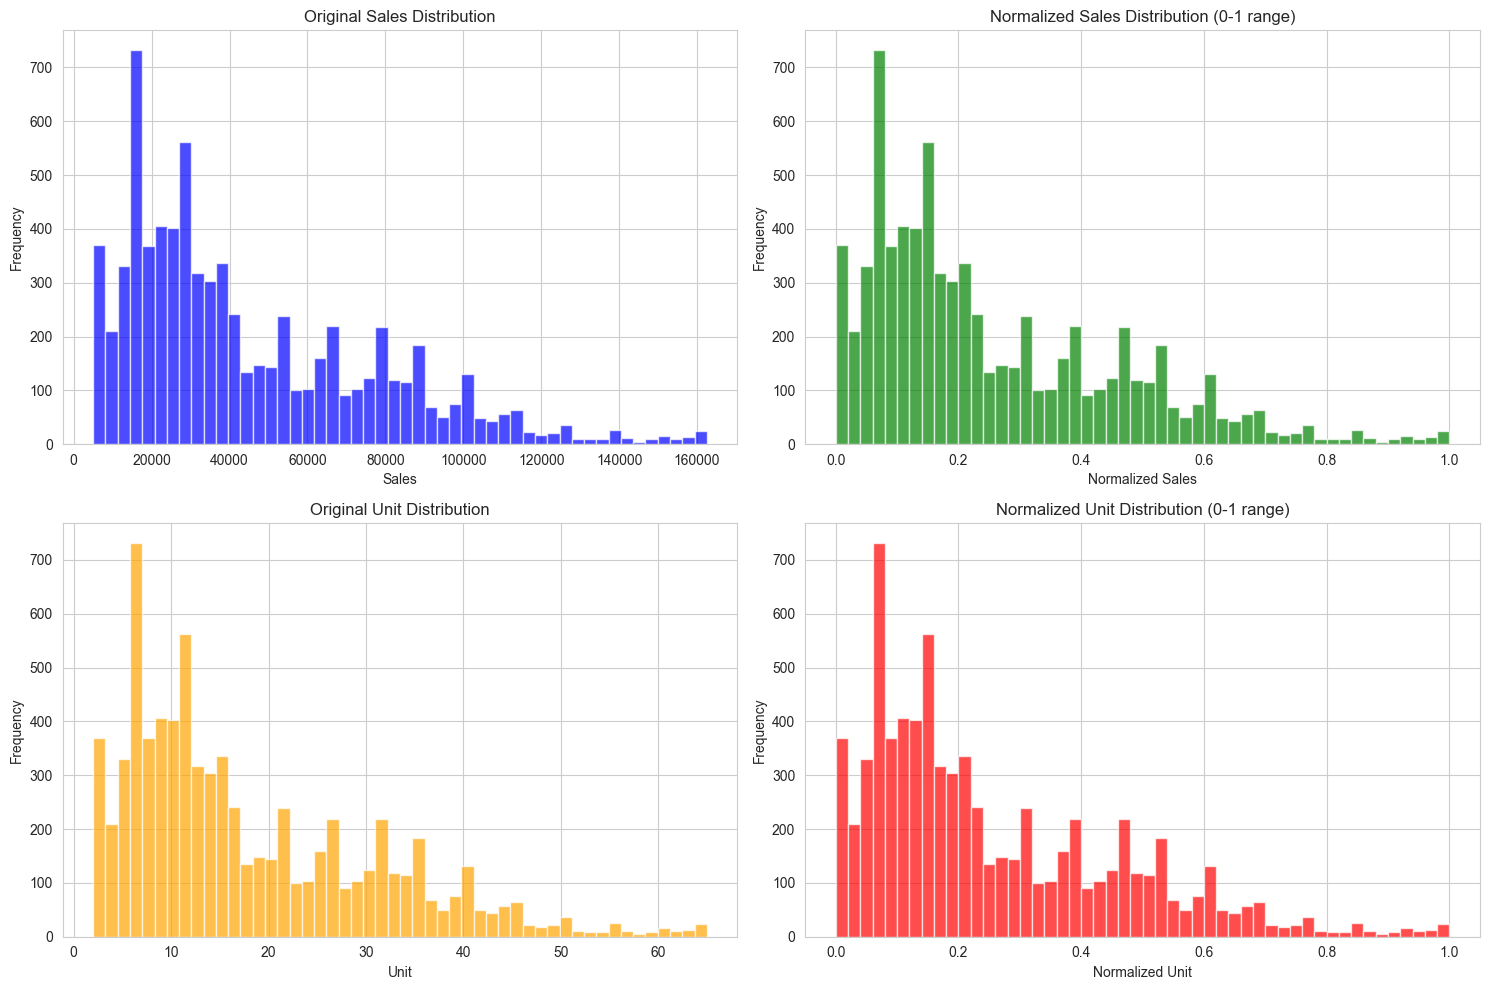


✓ Normalization completed successfully!


In [22]:
# Apply Min-Max Normalization to Sales and Unit columns
from sklearn.preprocessing import MinMaxScaler

print("=" * 60)
print("DATA NORMALIZATION - MIN-MAX SCALING")
print("=" * 60)

# Store original values for comparison
df_normalized = df_clean.copy()

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Normalize Sales and Unit columns
columns_to_normalize = ['Sales', 'Unit']
df_normalized[columns_to_normalize] = scaler.fit_transform(df_clean[columns_to_normalize])

print("\nOriginal Sales statistics:")
print(df_clean['Sales'].describe())

print("\nNormalized Sales statistics:")
print(df_normalized['Sales'].describe())

print("\nOriginal Unit statistics:")
print(df_clean['Unit'].describe())

print("\nNormalized Unit statistics:")
print(df_normalized['Unit'].describe())

# Display comparison
print("\n" + "=" * 60)
print("COMPARISON: ORIGINAL vs NORMALIZED (First 10 rows)")
print("=" * 60)
comparison_df = pd.DataFrame({
    'Original_Sales': df_clean['Sales'].head(10),
    'Normalized_Sales': df_normalized['Sales'].head(10),
    'Original_Unit': df_clean['Unit'].head(10),
    'Normalized_Unit': df_normalized['Unit'].head(10)
})
print(comparison_df)

# Visualize the normalization effect
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Original Sales distribution
axes[0, 0].hist(df_clean['Sales'], bins=50, color='blue', alpha=0.7)
axes[0, 0].set_title('Original Sales Distribution')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')

# Normalized Sales distribution
axes[0, 1].hist(df_normalized['Sales'], bins=50, color='green', alpha=0.7)
axes[0, 1].set_title('Normalized Sales Distribution (0-1 range)')
axes[0, 1].set_xlabel('Normalized Sales')
axes[0, 1].set_ylabel('Frequency')

# Original Unit distribution
axes[1, 0].hist(df_clean['Unit'], bins=50, color='orange', alpha=0.7)
axes[1, 0].set_title('Original Unit Distribution')
axes[1, 0].set_xlabel('Unit')
axes[1, 0].set_ylabel('Frequency')

# Normalized Unit distribution
axes[1, 1].hist(df_normalized['Unit'], bins=50, color='red', alpha=0.7)
axes[1, 1].set_title('Normalized Unit Distribution (0-1 range)')
axes[1, 1].set_xlabel('Normalized Unit')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n✓ Normalization completed successfully!")

### 2.6 GroupBy Function Analysis

**Explanation:**
**GroupBy() Function:**
- Groups data by one or more columns
- Allows aggregation operations (sum, mean, count, etc.)
- Useful for data chunking (splitting data into groups) and merging (combining grouped results)

**Use Cases:**
1. **Data Chunking**: Split data into groups for separate analysis
2. **Data Merging**: Combine grouped data with aggregated statistics
3. **Comparative Analysis**: Compare groups side by side

**Recommendation:** GroupBy is essential for this analysis because we need to:
- Analyze sales by State
- Analyze sales by Group (Kids, Men, Women, Seniors)
- Analyze sales by Time period
- Generate weekly, monthly, and quarterly reports

In [23]:
# Demonstrate GroupBy functionality
print("=" * 60)
print("GROUPBY FUNCTION ANALYSIS")
print("=" * 60)

# Example 1: Group by State and calculate total sales
print("\n1. GROUPING BY STATE - Total Sales per State")
print("-" * 60)
state_sales = df_clean.groupby('State')['Sales'].agg(['sum', 'mean', 'count']).round(2)
state_sales.columns = ['Total_Sales', 'Average_Sales', 'Transaction_Count']
state_sales = state_sales.sort_values('Total_Sales', ascending=False)
print(state_sales)

# Example 2: Group by Group (demographic)
print("\n2. GROUPING BY DEMOGRAPHIC GROUP - Total Sales per Group")
print("-" * 60)
group_sales = df_clean.groupby('Group')['Sales'].agg(['sum', 'mean', 'count']).round(2)
group_sales.columns = ['Total_Sales', 'Average_Sales', 'Transaction_Count']
group_sales = group_sales.sort_values('Total_Sales', ascending=False)
print(group_sales)

# Example 3: Group by Time period
print("\n3. GROUPING BY TIME PERIOD - Total Sales per Time")
print("-" * 60)
time_sales = df_clean.groupby('Time')['Sales'].agg(['sum', 'mean', 'count']).round(2)
time_sales.columns = ['Total_Sales', 'Average_Sales', 'Transaction_Count']
time_sales = time_sales.sort_values('Total_Sales', ascending=False)
print(time_sales)

# Example 4: Multi-level grouping (State and Group)
print("\n4. MULTI-LEVEL GROUPING - Sales by State and Group")
print("-" * 60)
state_group_sales = df_clean.groupby(['State', 'Group'])['Sales'].sum().round(2)
print(state_group_sales.head(20))

# Example 5: Group by Date (for time series analysis)
print("\n5. GROUPING BY DATE - Daily Sales")
print("-" * 60)
daily_sales = df_clean.groupby('Date')['Sales'].agg(['sum', 'mean']).round(2)
daily_sales.columns = ['Daily_Total_Sales', 'Daily_Avg_Sales']
print(daily_sales.head(10))

print("\n" + "=" * 60)
print("GROUPBY INSIGHTS")
print("=" * 60)
print("""
GroupBy is essential for this analysis because it allows us to:
1. Chunk data into meaningful groups (State, Group, Time)
2. Merge aggregated statistics for comparison
3. Perform comparative analysis across different dimensions
4. Generate reports at different time granularities (daily, weekly, monthly, quarterly)
""")

GROUPBY FUNCTION ANALYSIS

1. GROUPING BY STATE - Total Sales per State
------------------------------------------------------------
       Total_Sales  Average_Sales  Transaction_Count
State                                               
VIC      105565000       97745.37               1080
NSW       74970000       69416.67               1080
SA        58857500       54497.69               1080
QLD       33417500       30942.13               1080
TAS       22760000       21074.07               1080
NT        22580000       20907.41               1080
WA        22152500       20511.57               1080

2. GROUPING BY DEMOGRAPHIC GROUP - Total Sales per Group
------------------------------------------------------------
         Total_Sales  Average_Sales  Transaction_Count
Group                                                 
Men         85750000       45370.37               1890
Women       85442500       45207.67               1890
Kids        85072500       45011.90               1

## Step 3: Data Analysis

### 3.1 Descriptive Statistical Analysis

**Explanation:**
**Descriptive Statistics** help us understand the central tendency and variability of our data:
- **Mean**: Average value (sum of all values / count)
- **Median**: Middle value when data is sorted (less affected by outliers)
- **Mode**: Most frequently occurring value
- **Standard Deviation**: Measure of data spread/variability

**Why these metrics?**
- Mean: Shows average performance
- Median: Better for skewed data (less affected by outliers)
- Mode: Shows most common value
- Standard Deviation: Shows how spread out the data is

DESCRIPTIVE STATISTICAL ANALYSIS

SALES COLUMN STATISTICS
Mean (Average): 45013.56
Median (Middle value): 35000.00
Mode (Most frequent): 22500
Standard Deviation: 32253.51
Variance: 1040288710.18
Minimum: 5000.00
Maximum: 162500.00
Range: 157500.00

UNIT COLUMN STATISTICS
Mean (Average): 18.01
Median (Middle value): 14.00
Mode (Most frequent): 9
Standard Deviation: 12.90
Variance: 166.45
Minimum: 2.00
Maximum: 65.00
Range: 63.00

SUMMARY STATISTICS TABLE
                 Sales       Unit
Mean      45013.558201  18.005423
Median    35000.000000  14.000000
Mode      22500.000000   9.000000
Std Dev   32253.506944  12.901403
Min        5000.000000   2.000000
Max      162500.000000  65.000000


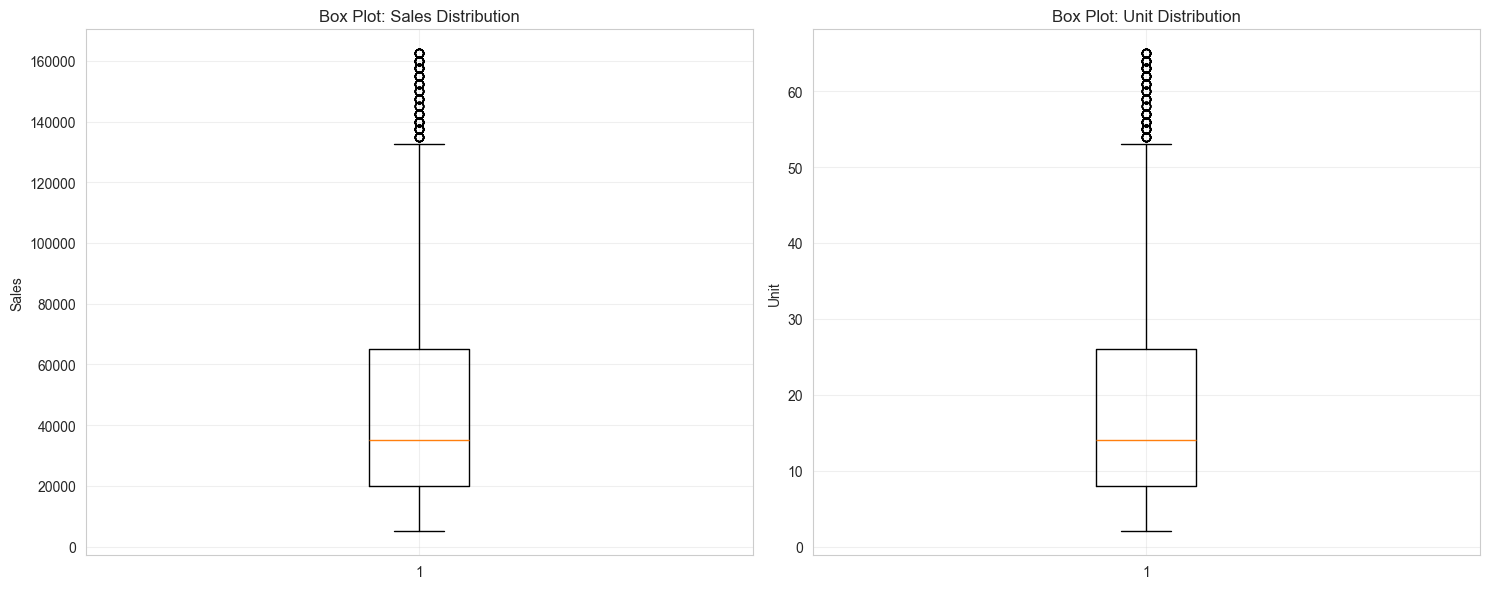

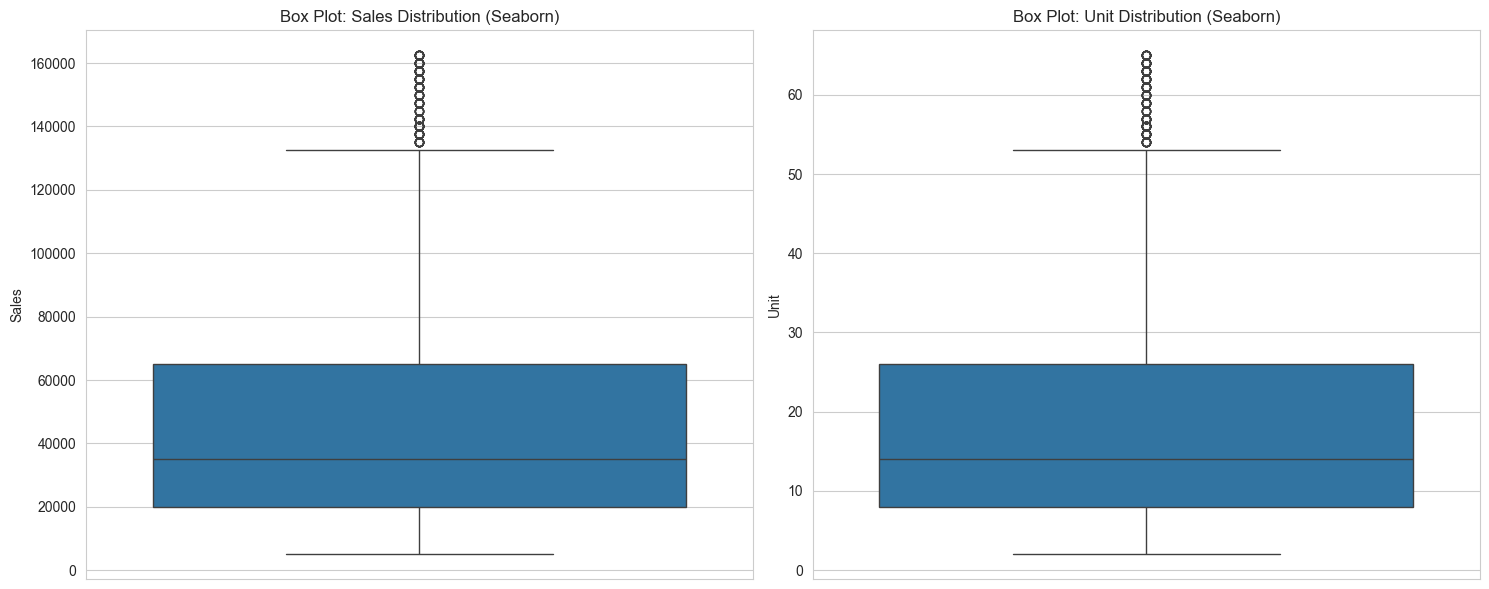

In [24]:
# Descriptive Statistics for Sales and Unit columns
from scipy import stats

print("=" * 60)
print("DESCRIPTIVE STATISTICAL ANALYSIS")
print("=" * 60)

# Sales Statistics
print("\n" + "=" * 60)
print("SALES COLUMN STATISTICS")
print("=" * 60)
sales_mean = df_clean['Sales'].mean()
sales_median = df_clean['Sales'].median()
sales_mode = df_clean['Sales'].mode()[0] if len(df_clean['Sales'].mode()) > 0 else 'No mode'
sales_std = df_clean['Sales'].std()
sales_min = df_clean['Sales'].min()
sales_max = df_clean['Sales'].max()
sales_range = sales_max - sales_min
sales_variance = df_clean['Sales'].var()

print(f"Mean (Average): {sales_mean:.2f}")
print(f"Median (Middle value): {sales_median:.2f}")
print(f"Mode (Most frequent): {sales_mode}")
print(f"Standard Deviation: {sales_std:.2f}")
print(f"Variance: {sales_variance:.2f}")
print(f"Minimum: {sales_min:.2f}")
print(f"Maximum: {sales_max:.2f}")
print(f"Range: {sales_range:.2f}")

# Unit Statistics
print("\n" + "=" * 60)
print("UNIT COLUMN STATISTICS")
print("=" * 60)
unit_mean = df_clean['Unit'].mean()
unit_median = df_clean['Unit'].median()
unit_mode = df_clean['Unit'].mode()[0] if len(df_clean['Unit'].mode()) > 0 else 'No mode'
unit_std = df_clean['Unit'].std()
unit_min = df_clean['Unit'].min()
unit_max = df_clean['Unit'].max()
unit_range = unit_max - unit_min
unit_variance = df_clean['Unit'].var()

print(f"Mean (Average): {unit_mean:.2f}")
print(f"Median (Middle value): {unit_median:.2f}")
print(f"Mode (Most frequent): {unit_mode}")
print(f"Standard Deviation: {unit_std:.2f}")
print(f"Variance: {unit_variance:.2f}")
print(f"Minimum: {unit_min:.2f}")
print(f"Maximum: {unit_max:.2f}")
print(f"Range: {unit_range:.2f}")

# Create a summary DataFrame
stats_summary = pd.DataFrame({
    'Sales': [sales_mean, sales_median, sales_mode, sales_std, sales_min, sales_max],
    'Unit': [unit_mean, unit_median, unit_mode, unit_std, unit_min, unit_max]
}, index=['Mean', 'Median', 'Mode', 'Std Dev', 'Min', 'Max'])

print("\n" + "=" * 60)
print("SUMMARY STATISTICS TABLE")
print("=" * 60)
print(stats_summary)

# Box plot for descriptive statistics (as required)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot for Sales
axes[0].boxplot(df_clean['Sales'], vert=True)
axes[0].set_title('Box Plot: Sales Distribution')
axes[0].set_ylabel('Sales')
axes[0].grid(True, alpha=0.3)

# Box plot for Unit
axes[1].boxplot(df_clean['Unit'], vert=True)
axes[1].set_title('Box Plot: Unit Distribution')
axes[1].set_ylabel('Unit')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Using seaborn for better box plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(y=df_clean['Sales'], ax=axes[0])
axes[0].set_title('Box Plot: Sales Distribution (Seaborn)')
sns.boxplot(y=df_clean['Unit'], ax=axes[1])
axes[1].set_title('Box Plot: Unit Distribution (Seaborn)')
plt.tight_layout()
plt.show()

### 3.2 Identifying Highest and Lowest Sales Groups

**Explanation:**
We need to identify which demographic groups (Kids, Men, Women, Seniors) have:
- Highest total sales
- Lowest total sales

This helps the company understand which customer segments are most valuable.

GROUP-WISE SALES ANALYSIS

Sales by Group (sorted by Total Sales):
         Total_Sales  Average_Sales  Transaction_Count
Group                                                 
Men         85750000       45370.37               1890
Women       85442500       45207.67               1890
Kids        85072500       45011.90               1890
Seniors     84037500       44464.29               1890

KEY FINDINGS
✓ Group with HIGHEST Total Sales: Men
  Total Sales: $85,750,000.00
  Average Sales per Transaction: $45,370.37
  Number of Transactions: 1890

✓ Group with LOWEST Total Sales: Seniors
  Total Sales: $84,037,500.00
  Average Sales per Transaction: $44,464.29
  Number of Transactions: 1890

📊 Sales Difference: $1,712,500.00
   The highest group generates $1,712,500.00 more than the lowest group


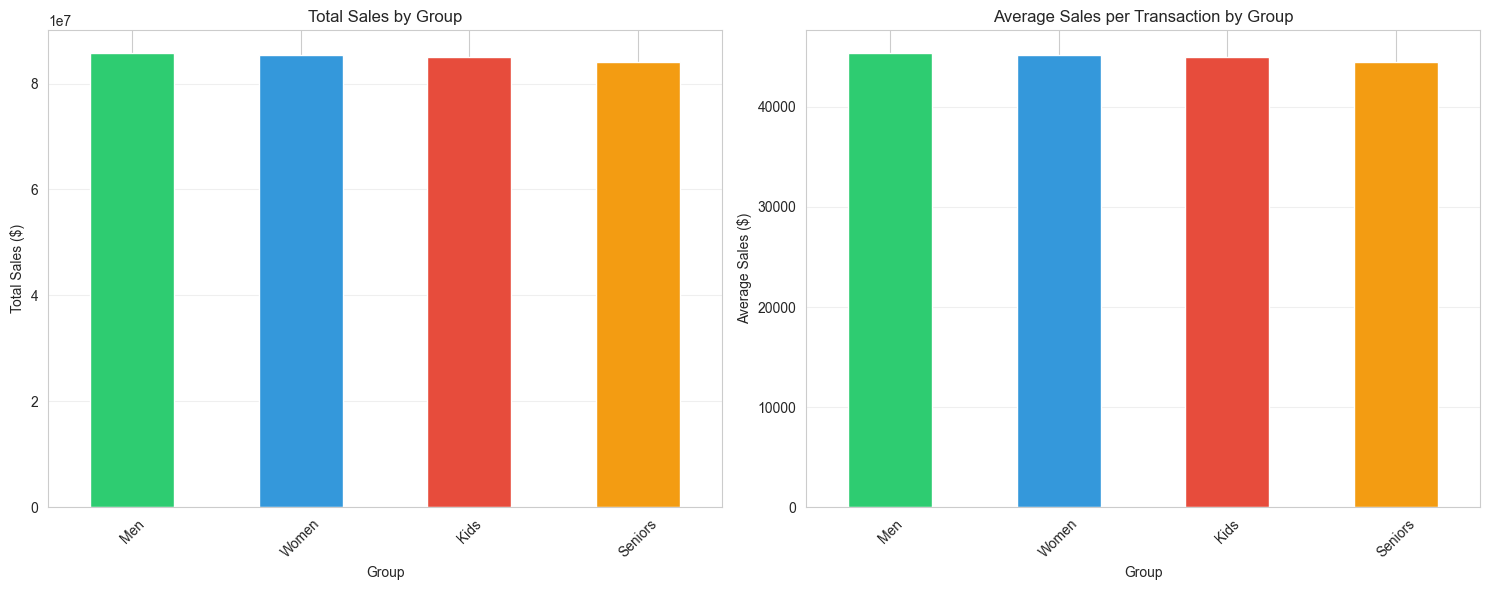

In [25]:
# Identify highest and lowest sales groups
print("=" * 60)
print("GROUP-WISE SALES ANALYSIS")
print("=" * 60)

# Calculate total sales by group
group_sales_total = df_clean.groupby('Group')['Sales'].agg(['sum', 'mean', 'count']).round(2)
group_sales_total.columns = ['Total_Sales', 'Average_Sales', 'Transaction_Count']
group_sales_total = group_sales_total.sort_values('Total_Sales', ascending=False)

print("\nSales by Group (sorted by Total Sales):")
print(group_sales_total)

# Identify highest and lowest
highest_group = group_sales_total.index[0]
lowest_group = group_sales_total.index[-1]

print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print(f"✓ Group with HIGHEST Total Sales: {highest_group}")
print(f"  Total Sales: ${group_sales_total.loc[highest_group, 'Total_Sales']:,.2f}")
print(f"  Average Sales per Transaction: ${group_sales_total.loc[highest_group, 'Average_Sales']:,.2f}")
print(f"  Number of Transactions: {int(group_sales_total.loc[highest_group, 'Transaction_Count'])}")

print(f"\n✓ Group with LOWEST Total Sales: {lowest_group}")
print(f"  Total Sales: ${group_sales_total.loc[lowest_group, 'Total_Sales']:,.2f}")
print(f"  Average Sales per Transaction: ${group_sales_total.loc[lowest_group, 'Average_Sales']:,.2f}")
print(f"  Number of Transactions: {int(group_sales_total.loc[lowest_group, 'Transaction_Count'])}")

# Calculate difference
sales_difference = group_sales_total.loc[highest_group, 'Total_Sales'] - group_sales_total.loc[lowest_group, 'Total_Sales']
print(f"\n📊 Sales Difference: ${sales_difference:,.2f}")
print(f"   The highest group generates ${sales_difference:,.2f} more than the lowest group")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart for total sales by group
group_sales_total['Total_Sales'].plot(kind='bar', ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0].set_title('Total Sales by Group')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Bar chart for average sales by group
group_sales_total['Average_Sales'].plot(kind='bar', ax=axes[1], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1].set_title('Average Sales per Transaction by Group')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Average Sales ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.3 Identifying Highest and Lowest Sales States

**Explanation:**
We need to identify which states have:
- Highest total sales (for investment prioritization)
- Lowest total sales (for sales program development)

This directly addresses the CEO's requirements.

STATE-WISE SALES ANALYSIS

Sales by State (sorted by Total Sales):
       Total_Sales  Average_Sales  Transaction_Count
State                                               
VIC      105565000       97745.37               1080
NSW       74970000       69416.67               1080
SA        58857500       54497.69               1080
QLD       33417500       30942.13               1080
TAS       22760000       21074.07               1080
NT        22580000       20907.41               1080
WA        22152500       20511.57               1080

KEY FINDINGS - STATE ANALYSIS
✓ State with HIGHEST Total Sales: VIC
  Total Sales: $105,565,000.00
  Average Sales per Transaction: $97,745.37
  Number of Transactions: 1080

✓ State with LOWEST Total Sales: WA
  Total Sales: $22,152,500.00
  Average Sales per Transaction: $20,511.57
  Number of Transactions: 1080

📊 Sales Difference: $83,412,500.00
   The highest state generates $83,412,500.00 more than the lowest state


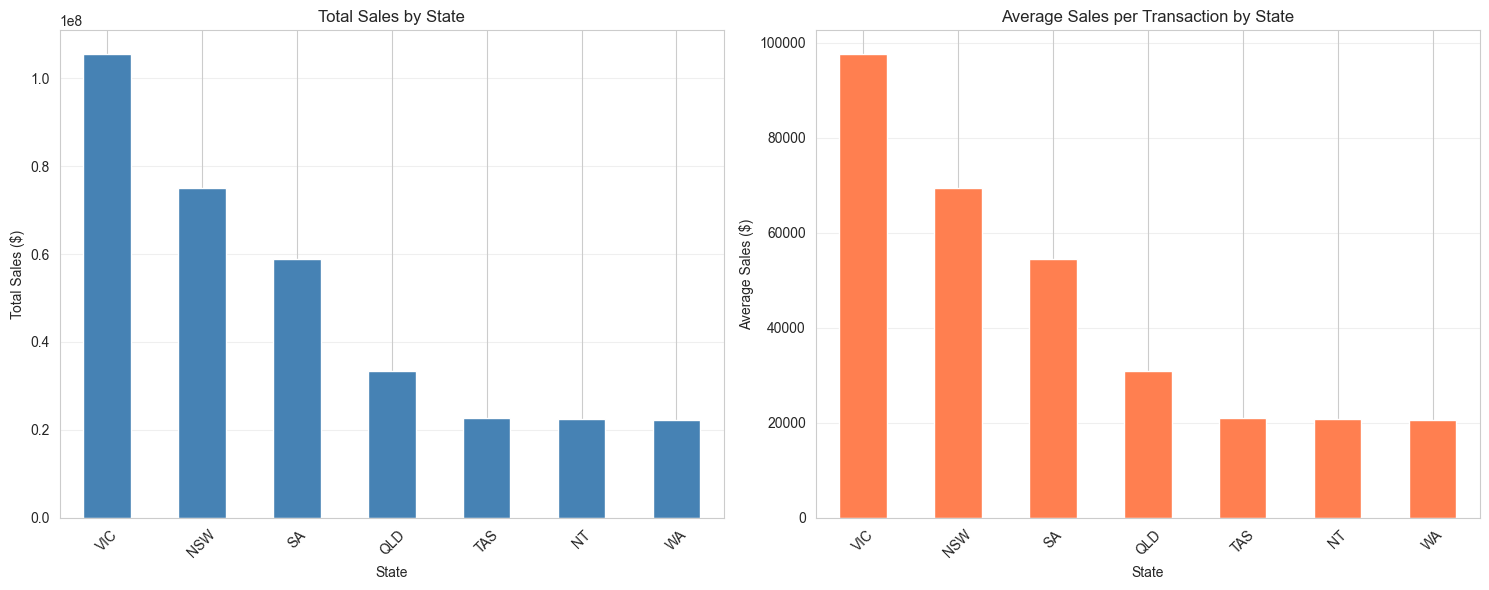

In [26]:
# Identify highest and lowest sales states
print("=" * 60)
print("STATE-WISE SALES ANALYSIS")
print("=" * 60)

# Calculate total sales by state
state_sales_total = df_clean.groupby('State')['Sales'].agg(['sum', 'mean', 'count']).round(2)
state_sales_total.columns = ['Total_Sales', 'Average_Sales', 'Transaction_Count']
state_sales_total = state_sales_total.sort_values('Total_Sales', ascending=False)

print("\nSales by State (sorted by Total Sales):")
print(state_sales_total)

# Identify highest and lowest
highest_state = state_sales_total.index[0]
lowest_state = state_sales_total.index[-1]

print("\n" + "=" * 60)
print("KEY FINDINGS - STATE ANALYSIS")
print("=" * 60)
print(f"✓ State with HIGHEST Total Sales: {highest_state}")
print(f"  Total Sales: ${state_sales_total.loc[highest_state, 'Total_Sales']:,.2f}")
print(f"  Average Sales per Transaction: ${state_sales_total.loc[highest_state, 'Average_Sales']:,.2f}")
print(f"  Number of Transactions: {int(state_sales_total.loc[highest_state, 'Transaction_Count'])}")

print(f"\n✓ State with LOWEST Total Sales: {lowest_state}")
print(f"  Total Sales: ${state_sales_total.loc[lowest_state, 'Total_Sales']:,.2f}")
print(f"  Average Sales per Transaction: ${state_sales_total.loc[lowest_state, 'Average_Sales']:,.2f}")
print(f"  Number of Transactions: {int(state_sales_total.loc[lowest_state, 'Transaction_Count'])}")

# Calculate difference
state_sales_difference = state_sales_total.loc[highest_state, 'Total_Sales'] - state_sales_total.loc[lowest_state, 'Total_Sales']
print(f"\n📊 Sales Difference: ${state_sales_difference:,.2f}")
print(f"   The highest state generates ${state_sales_difference:,.2f} more than the lowest state")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart for total sales by state
state_sales_total['Total_Sales'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Sales by State')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Bar chart for average sales by state
state_sales_total['Average_Sales'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Sales per Transaction by State')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Average Sales ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.4 Generating Weekly, Monthly, and Quarterly Reports

**Explanation:**
**Time-based Analysis:**
- **Daily Report**: Day-by-day sales performance
- **Weekly Report**: Sales aggregated by week
- **Monthly Report**: Sales aggregated by month (Oct, Nov, Dec for Q4)
- **Quarterly Report**: Overall Q4 2020 summary

This helps identify trends and patterns over time.

### 3.5 Additional EDA: Outlier Detection & Correlation Analysis

**Explanation:**
**Why Outlier Detection?**
- Outliers can skew statistical measures (mean, std dev)
- They may indicate data errors or special cases
- Important for understanding data quality

**Why Correlation Analysis?**
- Identifies relationships between variables
- Helps understand which features move together
- Useful for feature selection in ML models

**Note:** These are standard EDA steps that should be performed in most real-world problems.

OUTLIER DETECTION - IQR METHOD

Sales Column:
  Q1 (25th percentile): $20,000.00
  Q3 (75th percentile): $65,000.00
  IQR: $45,000.00
  Lower bound: $-47,500.00
  Upper bound: $132,500.00
  Number of outliers: 123 (1.63%)

Unit Column:
  Q1 (25th percentile): 8.00
  Q3 (75th percentile): 26.00
  IQR: 18.00
  Lower bound: -19.00
  Upper bound: 53.00
  Number of outliers: 123 (1.63%)


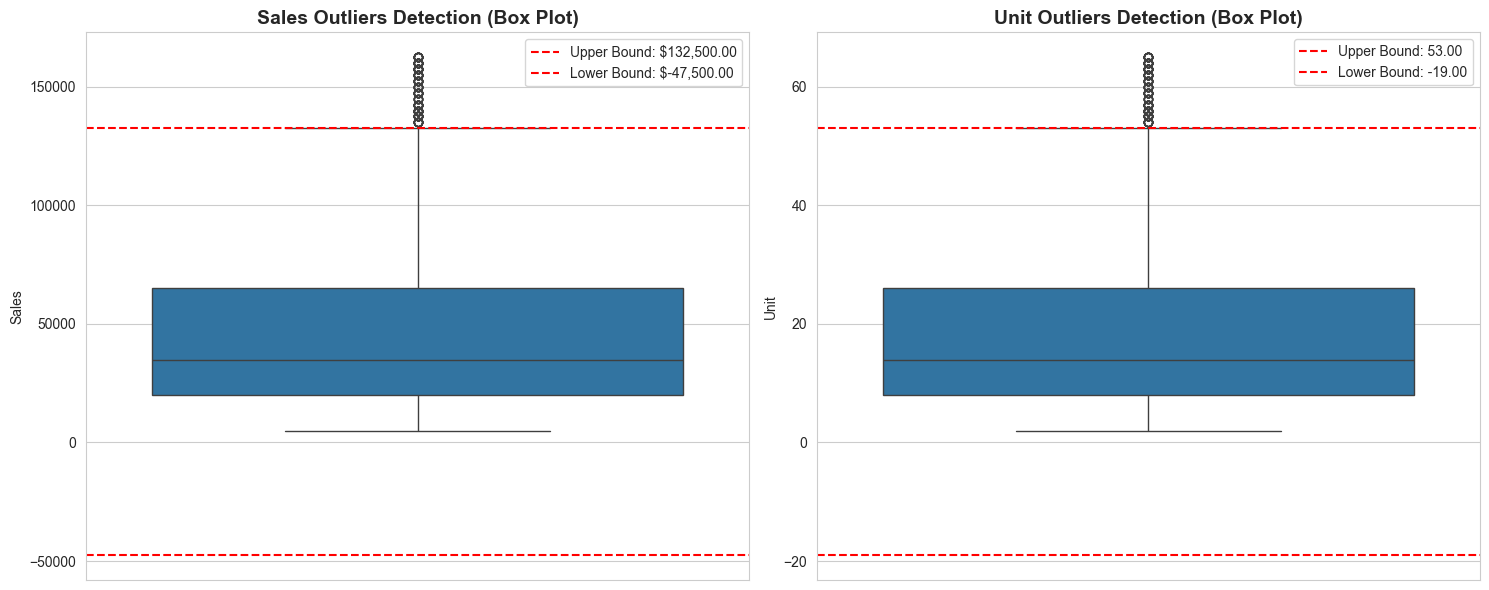


CORRELATION ANALYSIS

Correlation between Sales and Unit: 1.0000
Interpretation: Strong positive correlation

Correlation Matrix:
       Sales  Unit
Sales    1.0   1.0
Unit     1.0   1.0


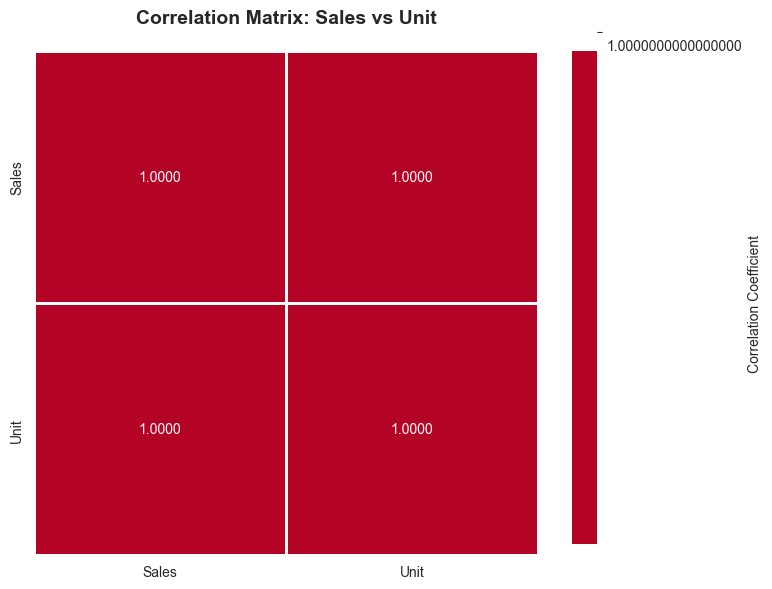

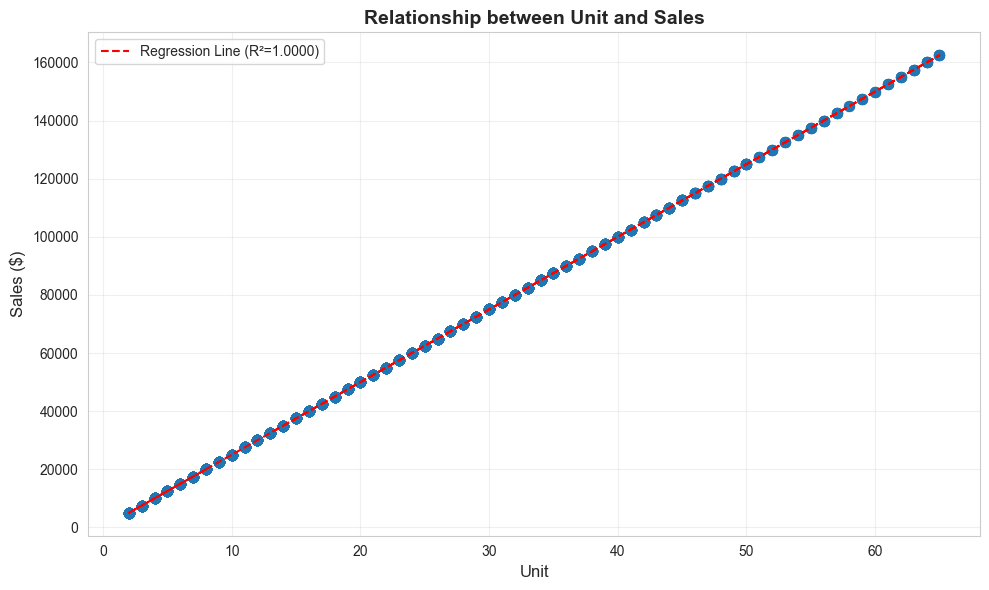


✓ Outlier detection and correlation analysis completed!


In [27]:
# Outlier Detection using IQR Method
print("=" * 60)
print("OUTLIER DETECTION - IQR METHOD")
print("=" * 60)

def detect_outliers_iqr(data, column):
    """Detect outliers using Interquartile Range (IQR) method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers in Sales
sales_outliers, sales_lower, sales_upper = detect_outliers_iqr(df_clean, 'Sales')
print(f"\nSales Column:")
print(f"  Q1 (25th percentile): ${df_clean['Sales'].quantile(0.25):,.2f}")
print(f"  Q3 (75th percentile): ${df_clean['Sales'].quantile(0.75):,.2f}")
print(f"  IQR: ${df_clean['Sales'].quantile(0.75) - df_clean['Sales'].quantile(0.25):,.2f}")
print(f"  Lower bound: ${sales_lower:,.2f}")
print(f"  Upper bound: ${sales_upper:,.2f}")
print(f"  Number of outliers: {len(sales_outliers)} ({len(sales_outliers)/len(df_clean)*100:.2f}%)")

# Detect outliers in Unit
unit_outliers, unit_lower, unit_upper = detect_outliers_iqr(df_clean, 'Unit')
print(f"\nUnit Column:")
print(f"  Q1 (25th percentile): {df_clean['Unit'].quantile(0.25):.2f}")
print(f"  Q3 (75th percentile): {df_clean['Unit'].quantile(0.75):.2f}")
print(f"  IQR: {df_clean['Unit'].quantile(0.75) - df_clean['Unit'].quantile(0.25):.2f}")
print(f"  Lower bound: {unit_lower:.2f}")
print(f"  Upper bound: {unit_upper:.2f}")
print(f"  Number of outliers: {len(unit_outliers)} ({len(unit_outliers)/len(df_clean)*100:.2f}%)")

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(y=df_clean['Sales'], ax=axes[0])
axes[0].set_title('Sales Outliers Detection (Box Plot)', fontsize=14, fontweight='bold')
axes[0].axhline(y=sales_upper, color='r', linestyle='--', label=f'Upper Bound: ${sales_upper:,.2f}')
axes[0].axhline(y=sales_lower, color='r', linestyle='--', label=f'Lower Bound: ${sales_lower:,.2f}')
axes[0].legend()

sns.boxplot(y=df_clean['Unit'], ax=axes[1])
axes[1].set_title('Unit Outliers Detection (Box Plot)', fontsize=14, fontweight='bold')
axes[1].axhline(y=unit_upper, color='r', linestyle='--', label=f'Upper Bound: {unit_upper:.2f}')
axes[1].axhline(y=unit_lower, color='r', linestyle='--', label=f'Lower Bound: {unit_lower:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Correlation Analysis
print("\n" + "=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Calculate correlation between Sales and Unit
correlation = df_clean['Sales'].corr(df_clean['Unit'])
print(f"\nCorrelation between Sales and Unit: {correlation:.4f}")
print(f"Interpretation: {'Strong positive correlation' if abs(correlation) > 0.7 else 'Moderate correlation' if abs(correlation) > 0.3 else 'Weak correlation'}")

# Create correlation matrix (if we had more numerical columns)
numerical_cols = ['Sales', 'Unit']
correlation_matrix = df_clean[numerical_cols].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize correlation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.4f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix: Sales vs Unit', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Scatter plot to visualize relationship
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Unit'], df_clean['Sales'], alpha=0.5, s=50)
plt.xlabel('Unit', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.title('Relationship between Unit and Sales', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add regression line
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(df_clean['Unit'], df_clean['Sales'])
line = slope * df_clean['Unit'] + intercept
plt.plot(df_clean['Unit'], line, 'r--', label=f'Regression Line (R²={r_value**2:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

print("\n✓ Outlier detection and correlation analysis completed!")

### 3.6 Distribution Analysis: Skewness & Kurtosis

**Explanation:**
**Skewness**: Measures asymmetry of data distribution
- Positive skew: Right tail longer (mean > median)
- Negative skew: Left tail longer (mean < median)
- Zero skew: Symmetric distribution

**Kurtosis**: Measures "tailedness" of distribution
- High kurtosis: Heavy tails, more outliers
- Low kurtosis: Light tails, fewer outliers
- Normal distribution has kurtosis ≈ 3

These metrics help understand data distribution shape.

DISTRIBUTION ANALYSIS: SKEWNESS & KURTOSIS

Sales Column Distribution:
  Skewness: 1.0853
  → Positively skewed (right tail longer)
  → Mean (45013.56) > Median (35000.00)

  Kurtosis: 0.6602
  → Light tails (fewer outliers than normal distribution)

Unit Column Distribution:
  Skewness: 1.0853
  → Positively skewed (right tail longer)
  → Mean (18.01) > Median (14.00)

  Kurtosis: 0.6602
  → Light tails (fewer outliers than normal distribution)


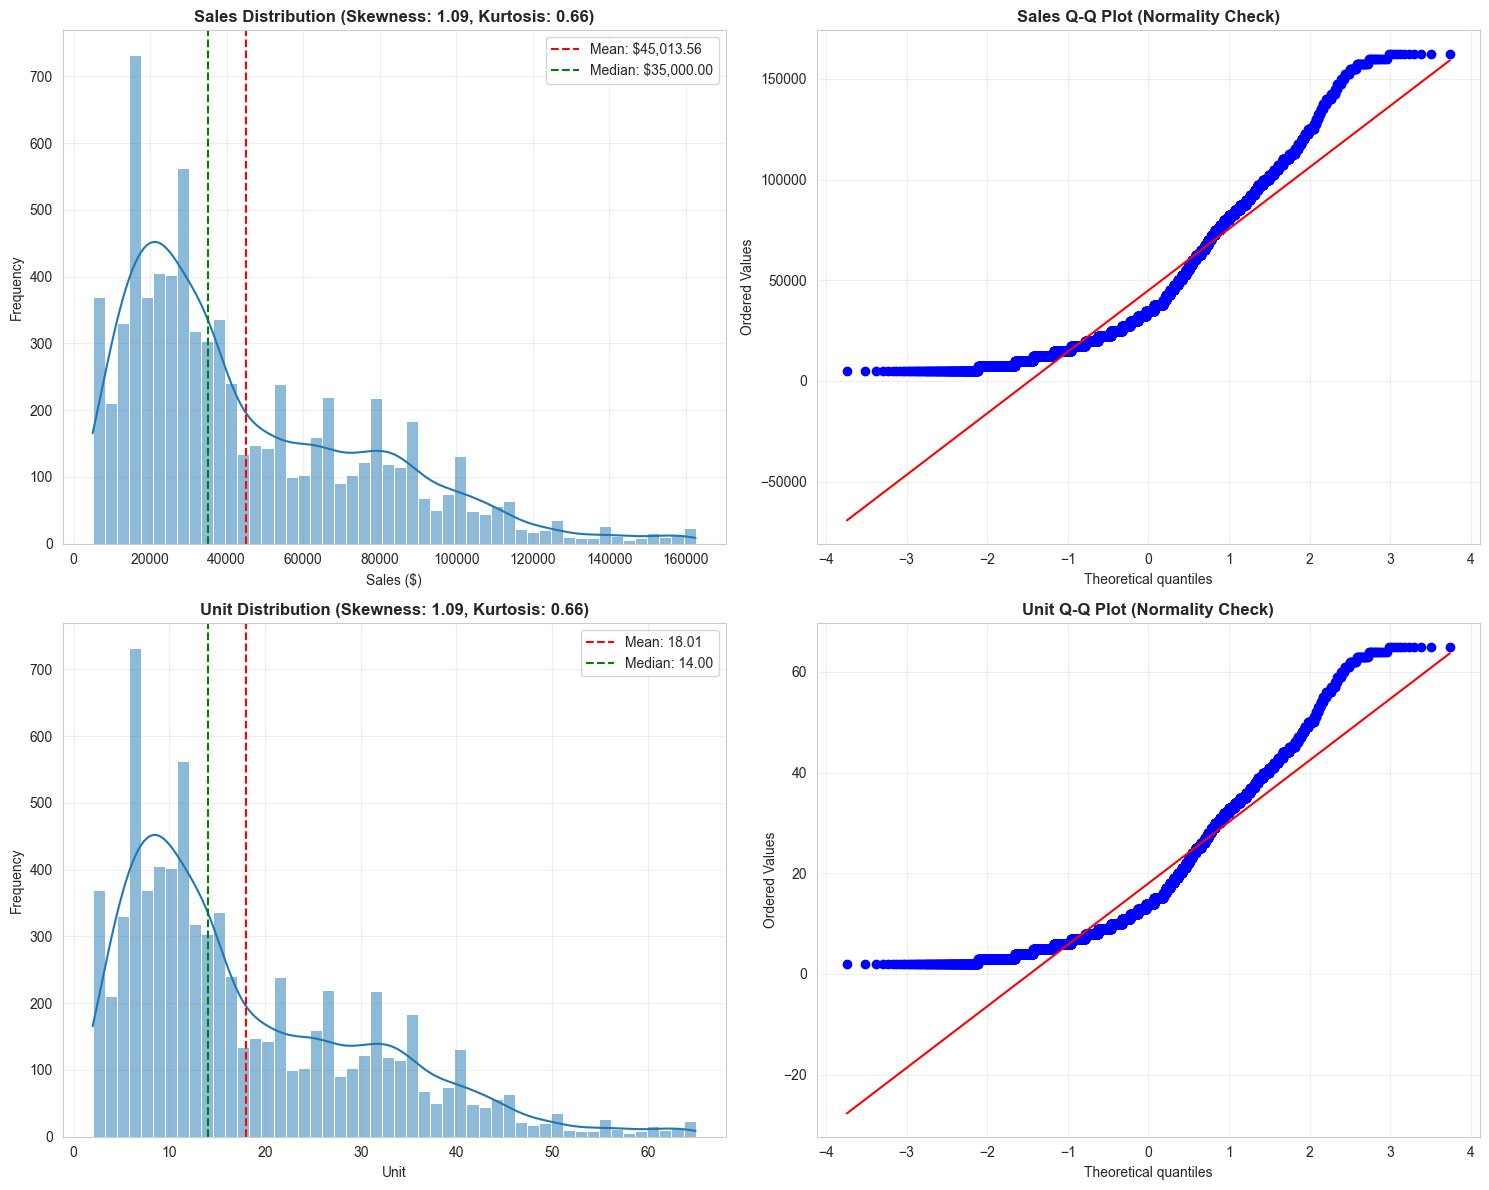


✓ Distribution analysis completed!


In [28]:
# Distribution Analysis: Skewness and Kurtosis
from scipy.stats import skew, kurtosis

print("=" * 60)
print("DISTRIBUTION ANALYSIS: SKEWNESS & KURTOSIS")
print("=" * 60)

# Sales distribution analysis
sales_skew = skew(df_clean['Sales'])
sales_kurt = kurtosis(df_clean['Sales'])

print("\nSales Column Distribution:")
print(f"  Skewness: {sales_skew:.4f}")
if sales_skew > 0:
    print(f"  → Positively skewed (right tail longer)")
    print(f"  → Mean ({df_clean['Sales'].mean():.2f}) > Median ({df_clean['Sales'].median():.2f})")
elif sales_skew < 0:
    print(f"  → Negatively skewed (left tail longer)")
    print(f"  → Mean ({df_clean['Sales'].mean():.2f}) < Median ({df_clean['Sales'].median():.2f})")
else:
    print(f"  → Symmetric distribution")

print(f"\n  Kurtosis: {sales_kurt:.4f}")
if sales_kurt > 3:
    print(f"  → Heavy tails (more outliers than normal distribution)")
elif sales_kurt < 3:
    print(f"  → Light tails (fewer outliers than normal distribution)")
else:
    print(f"  → Similar to normal distribution")

# Unit distribution analysis
unit_skew = skew(df_clean['Unit'])
unit_kurt = kurtosis(df_clean['Unit'])

print("\nUnit Column Distribution:")
print(f"  Skewness: {unit_skew:.4f}")
if unit_skew > 0:
    print(f"  → Positively skewed (right tail longer)")
    print(f"  → Mean ({df_clean['Unit'].mean():.2f}) > Median ({df_clean['Unit'].median():.2f})")
elif unit_skew < 0:
    print(f"  → Negatively skewed (left tail longer)")
    print(f"  → Mean ({df_clean['Unit'].mean():.2f}) < Median ({df_clean['Unit'].median():.2f})")
else:
    print(f"  → Symmetric distribution")

print(f"\n  Kurtosis: {unit_kurt:.4f}")
if unit_kurt > 3:
    print(f"  → Heavy tails (more outliers than normal distribution)")
elif unit_kurt < 3:
    print(f"  → Light tails (fewer outliers than normal distribution)")
else:
    print(f"  → Similar to normal distribution")

# Visualize distributions with KDE
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Sales histogram with KDE
sns.histplot(df_clean['Sales'], kde=True, ax=axes[0, 0], bins=50)
axes[0, 0].axvline(df_clean['Sales'].mean(), color='r', linestyle='--', label=f'Mean: ${df_clean["Sales"].mean():,.2f}')
axes[0, 0].axvline(df_clean['Sales'].median(), color='g', linestyle='--', label=f'Median: ${df_clean["Sales"].median():,.2f}')
axes[0, 0].set_title(f'Sales Distribution (Skewness: {sales_skew:.2f}, Kurtosis: {sales_kurt:.2f})', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sales ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Sales Q-Q plot (to check normality)
from scipy.stats import probplot
probplot(df_clean['Sales'], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Sales Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Unit histogram with KDE
sns.histplot(df_clean['Unit'], kde=True, ax=axes[1, 0], bins=50)
axes[1, 0].axvline(df_clean['Unit'].mean(), color='r', linestyle='--', label=f'Mean: {df_clean["Unit"].mean():.2f}')
axes[1, 0].axvline(df_clean['Unit'].median(), color='g', linestyle='--', label=f'Median: {df_clean["Unit"].median():.2f}')
axes[1, 0].set_title(f'Unit Distribution (Skewness: {unit_skew:.2f}, Kurtosis: {unit_kurt:.2f})', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Unit')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Unit Q-Q plot
probplot(df_clean['Unit'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Unit Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Distribution analysis completed!")

TIME-BASED SALES REPORTS

DAILY SALES REPORT

Top 10 Days by Sales:
            Total_Sales  Avg_Sales  Transaction_Count  Total_Units  Avg_Units
Date                                                                         
2020-12-14      4765000   56726.19                 84         1906      22.69
2020-12-10      4717500   56160.71                 84         1887      22.46
2020-12-26      4715000   56130.95                 84         1886      22.45
2020-12-15      4657500   55446.43                 84         1863      22.18
2020-12-09      4655000   55416.67                 84         1862      22.17
2020-12-27      4637500   55208.33                 84         1855      22.08
2020-12-22      4635000   55178.57                 84         1854      22.07
2020-12-29      4607500   54851.19                 84         1843      21.94
2020-12-13      4605000   54821.43                 84         1842      21.93
2020-12-28      4595000   54702.38                 84         1838      21

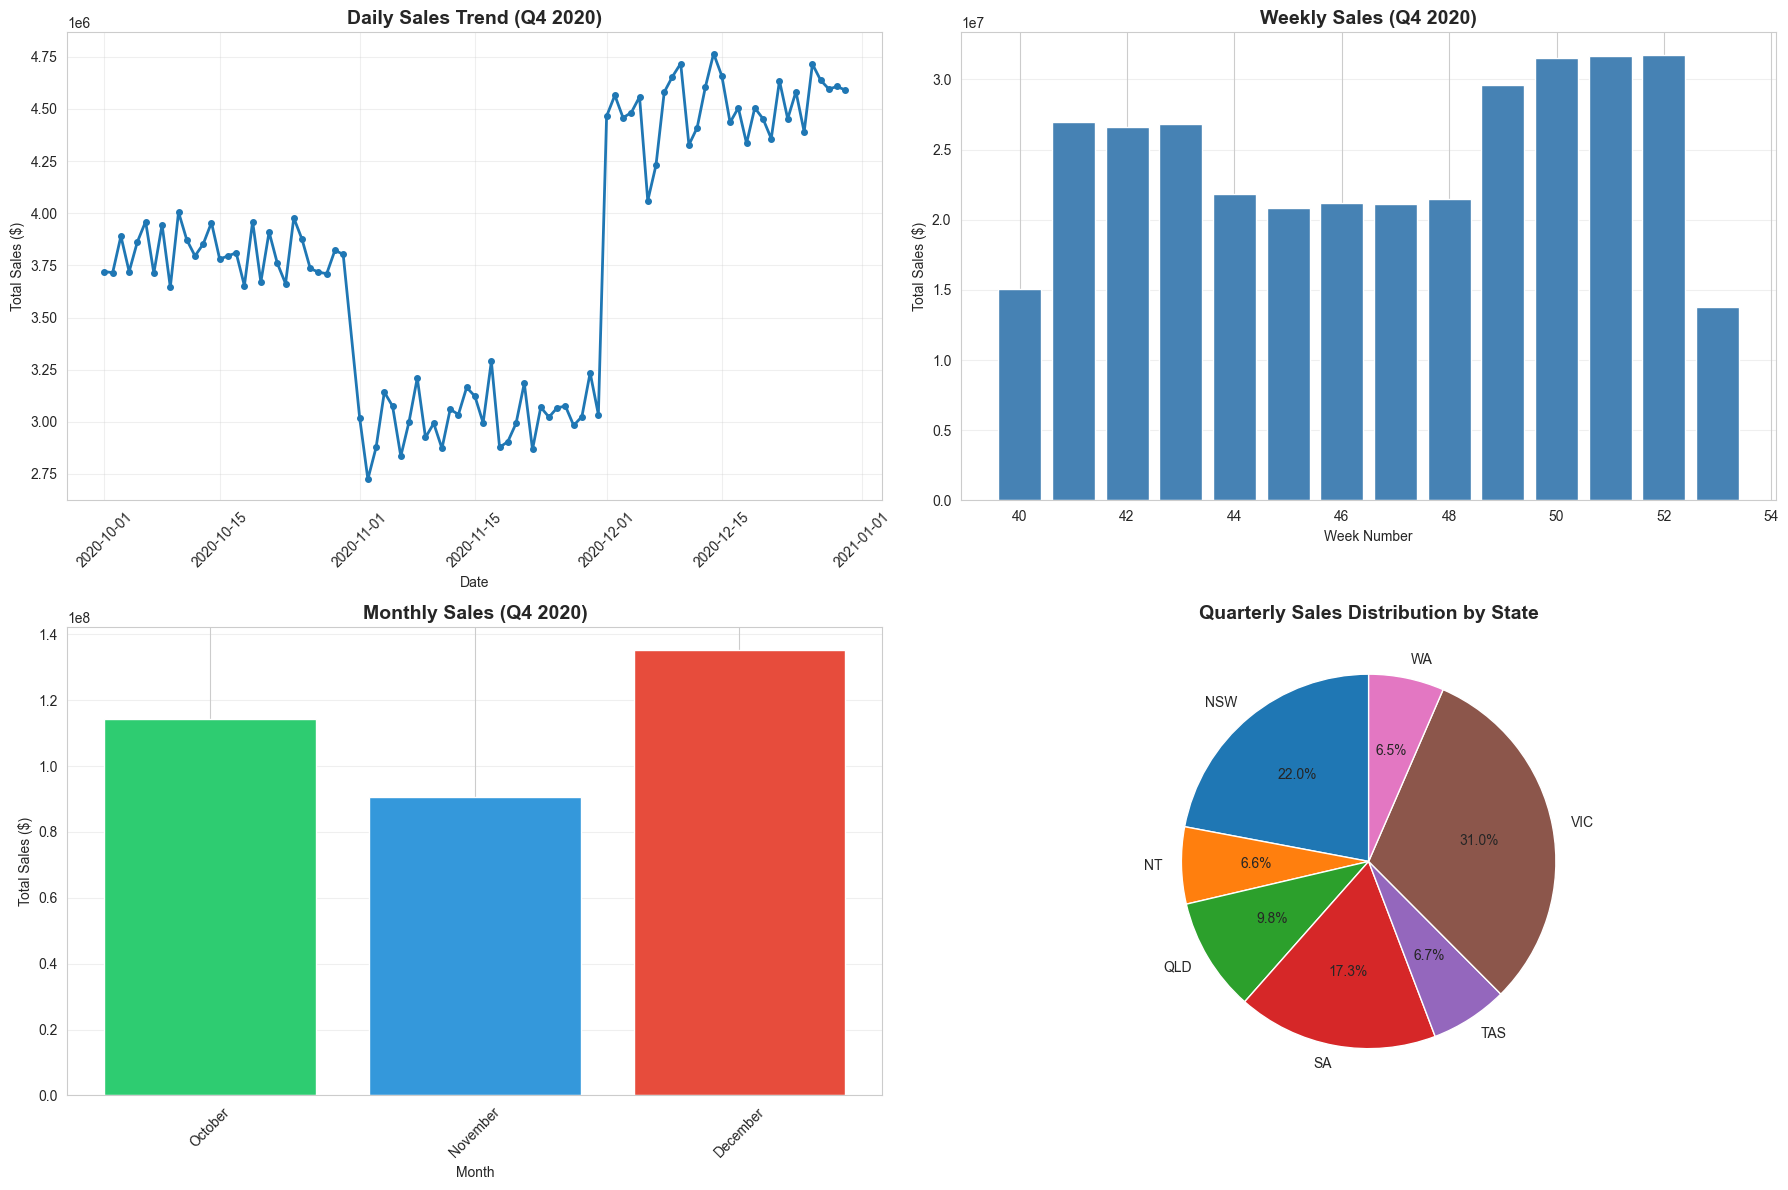

In [29]:
# Generate time-based reports
print("=" * 60)
print("TIME-BASED SALES REPORTS")
print("=" * 60)

# Add time-based columns
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Month_Name'] = df_clean['Date'].dt.strftime('%B')
df_clean['Week'] = df_clean['Date'].dt.isocalendar().week
df_clean['Day'] = df_clean['Date'].dt.day

# DAILY REPORT
print("\n" + "=" * 60)
print("DAILY SALES REPORT")
print("=" * 60)
daily_report = df_clean.groupby('Date').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Unit': ['sum', 'mean']
}).round(2)
daily_report.columns = ['Total_Sales', 'Avg_Sales', 'Transaction_Count', 'Total_Units', 'Avg_Units']
daily_report = daily_report.sort_values('Total_Sales', ascending=False)
print(f"\nTop 10 Days by Sales:")
print(daily_report.head(10))
print(f"\nBottom 10 Days by Sales:")
print(daily_report.tail(10))

# WEEKLY REPORT
print("\n" + "=" * 60)
print("WEEKLY SALES REPORT")
print("=" * 60)
weekly_report = df_clean.groupby('Week').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Unit': ['sum', 'mean']
}).round(2)
weekly_report.columns = ['Total_Sales', 'Avg_Sales', 'Transaction_Count', 'Total_Units', 'Avg_Units']
weekly_report = weekly_report.sort_values('Total_Sales', ascending=False)
print(weekly_report)

# MONTHLY REPORT
print("\n" + "=" * 60)
print("MONTHLY SALES REPORT (Q4 2020)")
print("=" * 60)
monthly_report = df_clean.groupby(['Month', 'Month_Name']).agg({
    'Sales': ['sum', 'mean', 'count'],
    'Unit': ['sum', 'mean']
}).round(2)
monthly_report.columns = ['Total_Sales', 'Avg_Sales', 'Transaction_Count', 'Total_Units', 'Avg_Units']
monthly_report = monthly_report.sort_values('Total_Sales', ascending=False)
print(monthly_report)

# QUARTERLY REPORT
print("\n" + "=" * 60)
print("QUARTERLY SALES REPORT (Q4 2020)")
print("=" * 60)
quarterly_total_sales = df_clean['Sales'].sum()
quarterly_avg_sales = df_clean['Sales'].mean()
quarterly_total_units = df_clean['Unit'].sum()
quarterly_avg_units = df_clean['Unit'].mean()
total_transactions = len(df_clean)

quarterly_report = pd.DataFrame({
    'Metric': ['Total Sales', 'Average Sales per Transaction', 'Total Units Sold', 
               'Average Units per Transaction', 'Total Transactions', 'Number of Days'],
    'Value': [quarterly_total_sales, quarterly_avg_sales, quarterly_total_units, 
              quarterly_avg_units, total_transactions, df_clean['Date'].nunique()]
})
print(quarterly_report.to_string(index=False))

# Visualization of time-based reports
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Daily sales trend
daily_sales_trend = df_clean.groupby('Date')['Sales'].sum()
axes[0, 0].plot(daily_sales_trend.index, daily_sales_trend.values, marker='o', linewidth=2, markersize=4)
axes[0, 0].set_title('Daily Sales Trend (Q4 2020)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Total Sales ($)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Weekly sales
weekly_sales = df_clean.groupby('Week')['Sales'].sum()
axes[0, 1].bar(weekly_sales.index, weekly_sales.values, color='steelblue')
axes[0, 1].set_title('Weekly Sales (Q4 2020)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Week Number')
axes[0, 1].set_ylabel('Total Sales ($)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Monthly sales
monthly_sales = df_clean.groupby('Month_Name')['Sales'].sum()
month_order = ['October', 'November', 'December']
monthly_sales = monthly_sales.reindex(month_order)
axes[1, 0].bar(monthly_sales.index, monthly_sales.values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1, 0].set_title('Monthly Sales (Q4 2020)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Total Sales ($)')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=45)

# Quarterly summary pie chart
state_sales_for_pie = df_clean.groupby('State')['Sales'].sum()
axes[1, 1].pie(state_sales_for_pie.values, labels=state_sales_for_pie.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Quarterly Sales Distribution by State', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 4: Data Visualization - Dashboard Creation

### 4.1 Visualization Library Recommendation

**Explanation:**
**Why Seaborn?**
- Built on matplotlib, provides statistical visualizations
- Better default aesthetics
- Easy to create complex plots
- Integrates well with pandas DataFrames
- Perfect for exploratory data analysis (EDA)

**Dashboard Requirements:**
1. State-wise sales analysis for different demographic groups
2. Group-wise sales analysis across various states
3. Time-of-day analysis (peak/off-peak periods)
4. Daily, weekly, monthly, and quarterly charts

### 4.2 State-wise Sales Analysis for Different Demographic Groups

**Explanation:**
This visualization shows how each state performs across different customer segments (Kids, Men, Women, Seniors). This helps identify:
- Which states are strong in which demographics
- Opportunities for targeted marketing
- State-specific customer preferences

STATE-WISE SALES BY DEMOGRAPHIC GROUP

State-Group Sales Matrix:
Group      Kids       Men   Seniors     Women
State                                        
NSW    18587500  19022500  18187500  19172500
NT      5700000   5762500   5465000   5652500
QLD     8510000   8392500   8190000   8325000
SA     14515000  14655000  14717500  14970000
TAS     5775000   5757500   5650000   5577500
VIC    26360000  26407500  26315000  26482500
WA      5625000   5752500   5512500   5262500


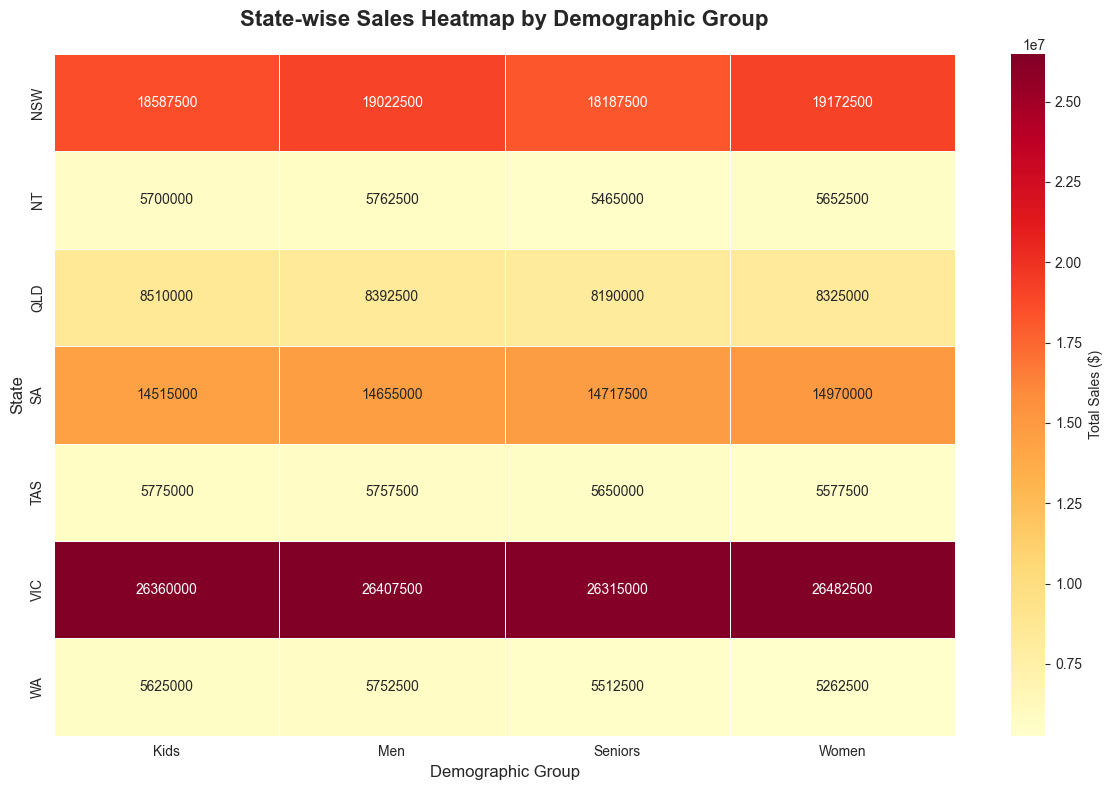

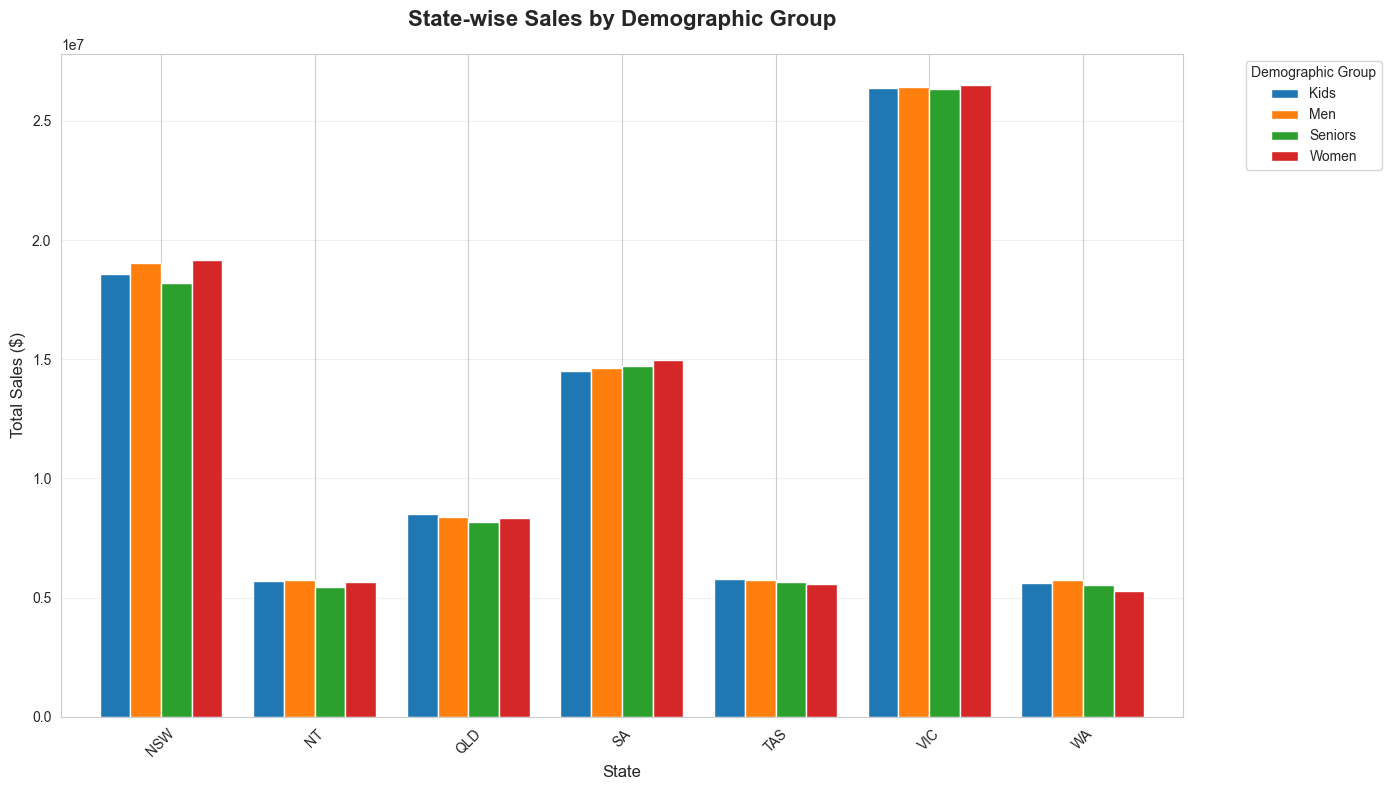

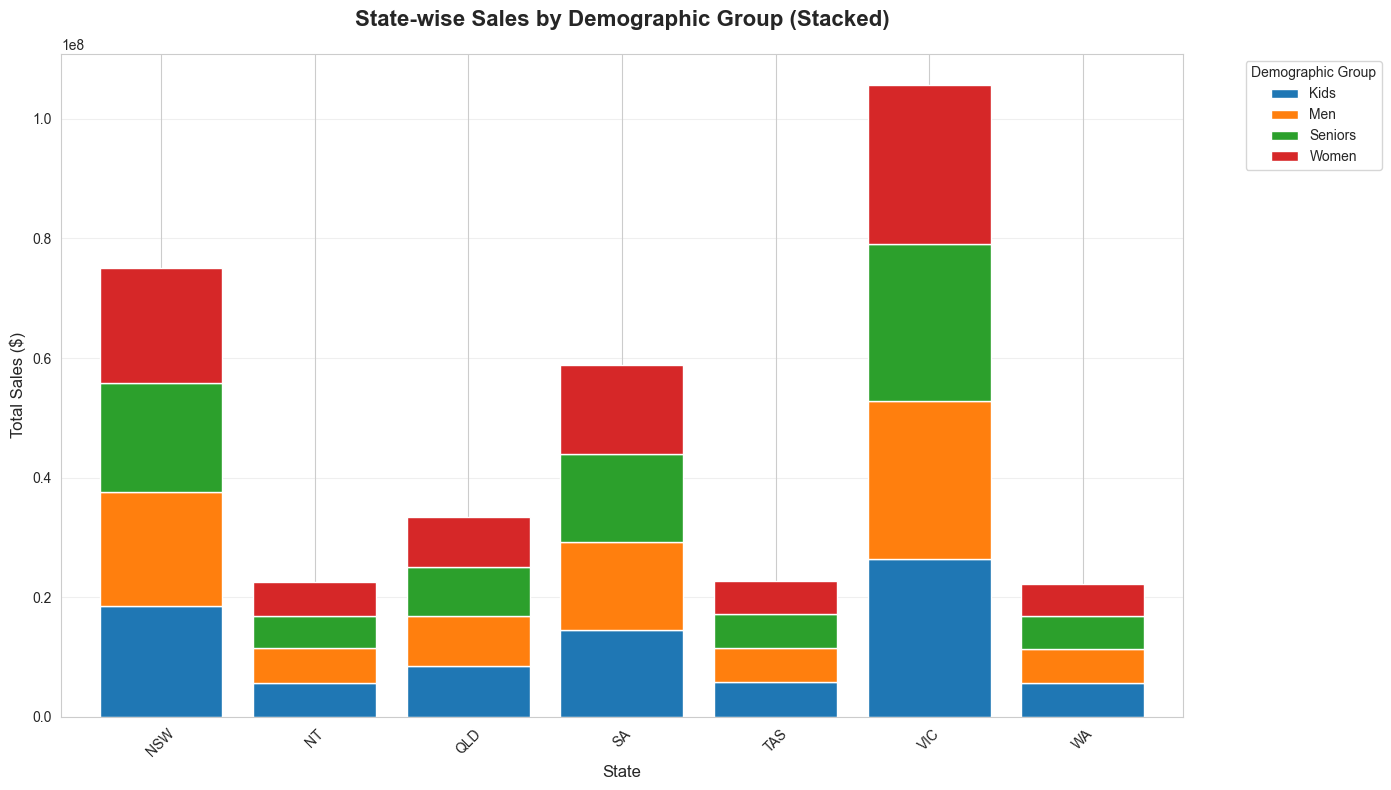

In [30]:
# State-wise sales analysis for different demographic groups
print("=" * 60)
print("STATE-WISE SALES BY DEMOGRAPHIC GROUP")
print("=" * 60)

# Create pivot table for state-group analysis
state_group_pivot = df_clean.pivot_table(values='Sales', index='State', columns='Group', aggfunc='sum')
print("\nState-Group Sales Matrix:")
print(state_group_pivot.round(2))

# Visualization 1: Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(state_group_pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Total Sales ($)'})
plt.title('State-wise Sales Heatmap by Demographic Group', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Demographic Group', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.show()

# Visualization 2: Grouped Bar Chart
state_group_pivot.plot(kind='bar', figsize=(14, 8), width=0.8)
plt.title('State-wise Sales by Demographic Group', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(title='Demographic Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Visualization 3: Stacked Bar Chart
state_group_pivot.plot(kind='bar', stacked=True, figsize=(14, 8), width=0.8)
plt.title('State-wise Sales by Demographic Group (Stacked)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(title='Demographic Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 4.3 Group-wise Sales Analysis Across Various States

**Explanation:**
This visualization shows how each demographic group performs across different states. This helps identify:
- Which groups are popular in which states
- State preferences for different demographics
- Opportunities for demographic-specific marketing strategies

GROUP-WISE SALES ACROSS STATES

Group-State Sales Matrix:
State         NSW       NT      QLD        SA      TAS       VIC       WA
Group                                                                    
Kids     18587500  5700000  8510000  14515000  5775000  26360000  5625000
Men      19022500  5762500  8392500  14655000  5757500  26407500  5752500
Seniors  18187500  5465000  8190000  14717500  5650000  26315000  5512500
Women    19172500  5652500  8325000  14970000  5577500  26482500  5262500


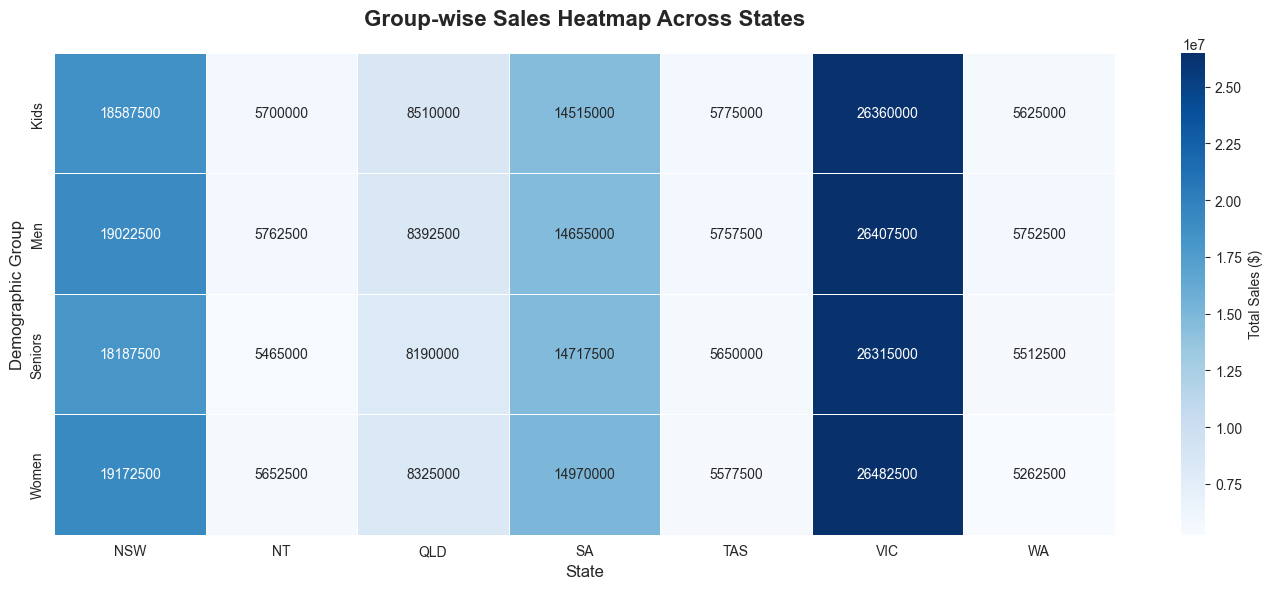

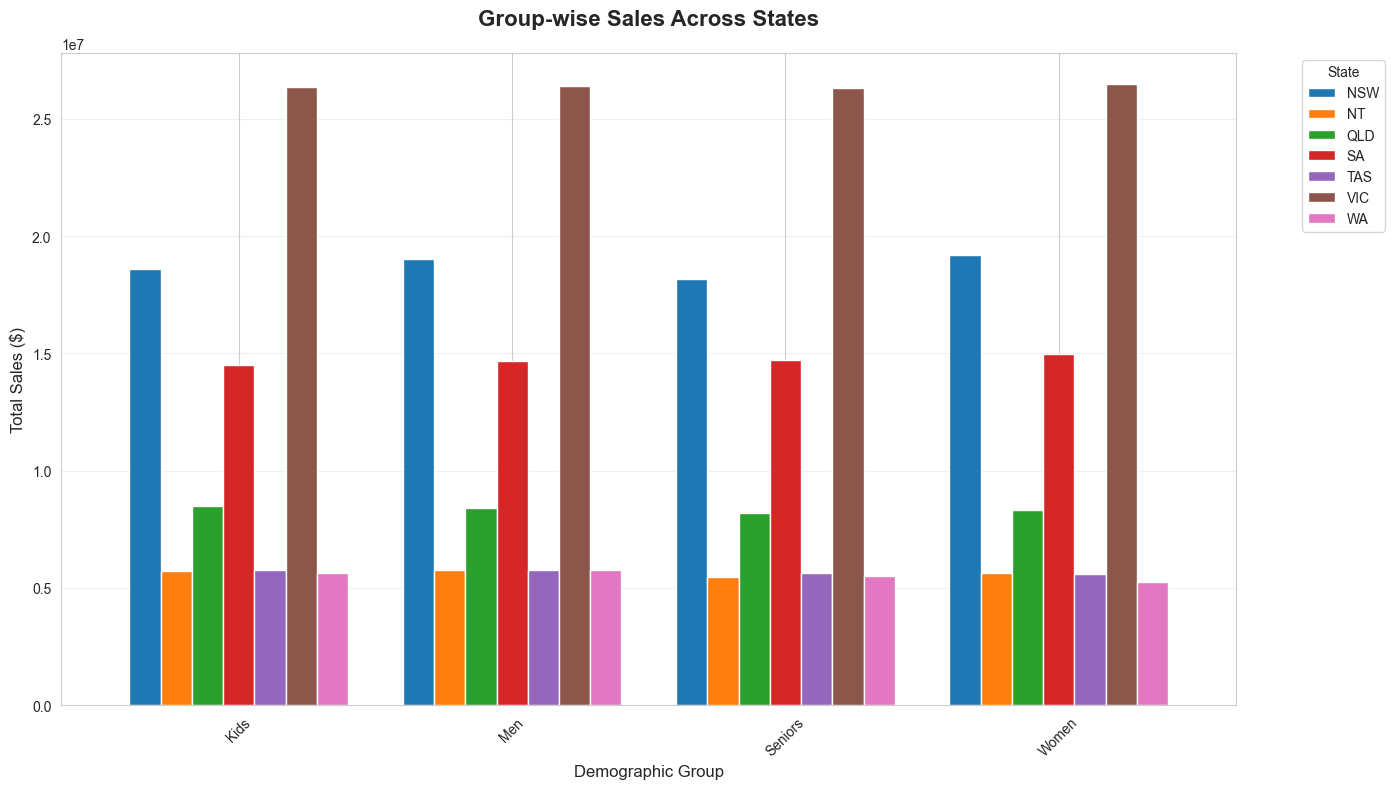

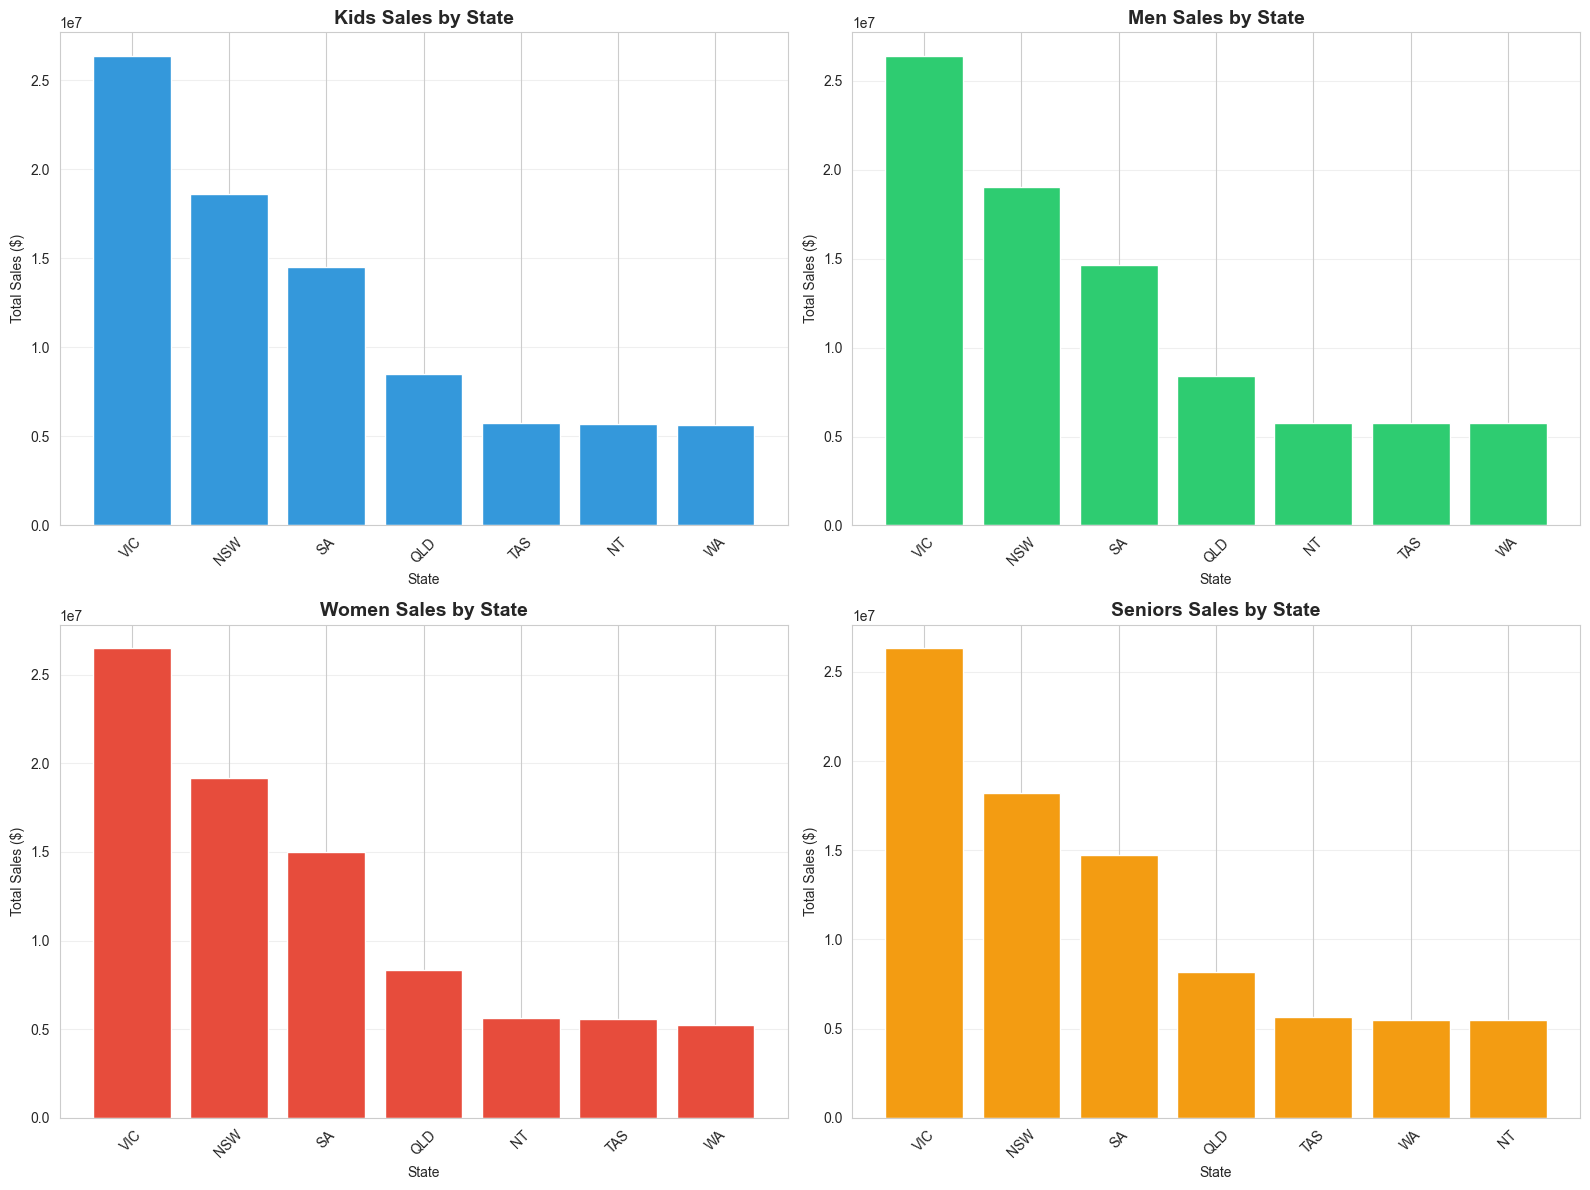

In [31]:
# Group-wise sales analysis across states
print("=" * 60)
print("GROUP-WISE SALES ACROSS STATES")
print("=" * 60)

# Create pivot table for group-state analysis
group_state_pivot = df_clean.pivot_table(values='Sales', index='Group', columns='State', aggfunc='sum')
print("\nGroup-State Sales Matrix:")
print(group_state_pivot.round(2))

# Visualization 1: Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(group_state_pivot, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5, cbar_kws={'label': 'Total Sales ($)'})
plt.title('Group-wise Sales Heatmap Across States', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('State', fontsize=12)
plt.ylabel('Demographic Group', fontsize=12)
plt.tight_layout()
plt.show()

# Visualization 2: Grouped Bar Chart
group_state_pivot.plot(kind='bar', figsize=(14, 8), width=0.8)
plt.title('Group-wise Sales Across States', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Demographic Group', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Visualization 3: Individual group analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
groups = ['Kids', 'Men', 'Women', 'Seniors']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, group in enumerate(groups):
    row = idx // 2
    col = idx % 2
    group_data = group_state_pivot.loc[group].sort_values(ascending=False)
    axes[row, col].bar(group_data.index, group_data.values, color=colors[idx])
    axes[row, col].set_title(f'{group} Sales by State', fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('State', fontsize=10)
    axes[row, col].set_ylabel('Total Sales ($)', fontsize=10)
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 4.4 Time-of-Day Analysis: Peak and Off-Peak Sales Periods

**Explanation:**
**Time-of-Day Analysis** helps identify:
- **Peak periods**: Times with highest sales (for resource allocation)
- **Off-peak periods**: Times with lowest sales (for promotional campaigns)
- Strategic planning for S&M teams
- Hyper-personalization opportunities
- Next Best Offer (NBO) timing

This is crucial for designing targeted marketing programs.

TIME-OF-DAY SALES ANALYSIS

Sales by Time Period:
           Total_Sales  Avg_Sales  Transaction_Count  Total_Units  Avg_Units
Time                                                                        
Morning      114207500   45320.44               2520        45683      18.13
Afternoon    114007500   45241.07               2520        45603      18.10
Evening      112087500   44479.17               2520        44835      17.79

PEAK AND OFF-PEAK ANALYSIS
✓ PEAK PERIOD: Morning
  Total Sales: $114,207,500.00
  Average Sales: $45,320.44
  Transactions: 2520

✓ OFF-PEAK PERIOD: Evening
  Total Sales: $112,087,500.00
  Average Sales: $44,479.17
  Transactions: 2520

TIME-OF-DAY ANALYSIS BY STATE
State           NSW       NT       QLD        SA      TAS       VIC       WA
Time                                                                        
Afternoon  25110000  7510000  11347500  20025000  7670000  35062500  7282500
Evening    24712500  7627500  10632500  19367500  7565000  34880

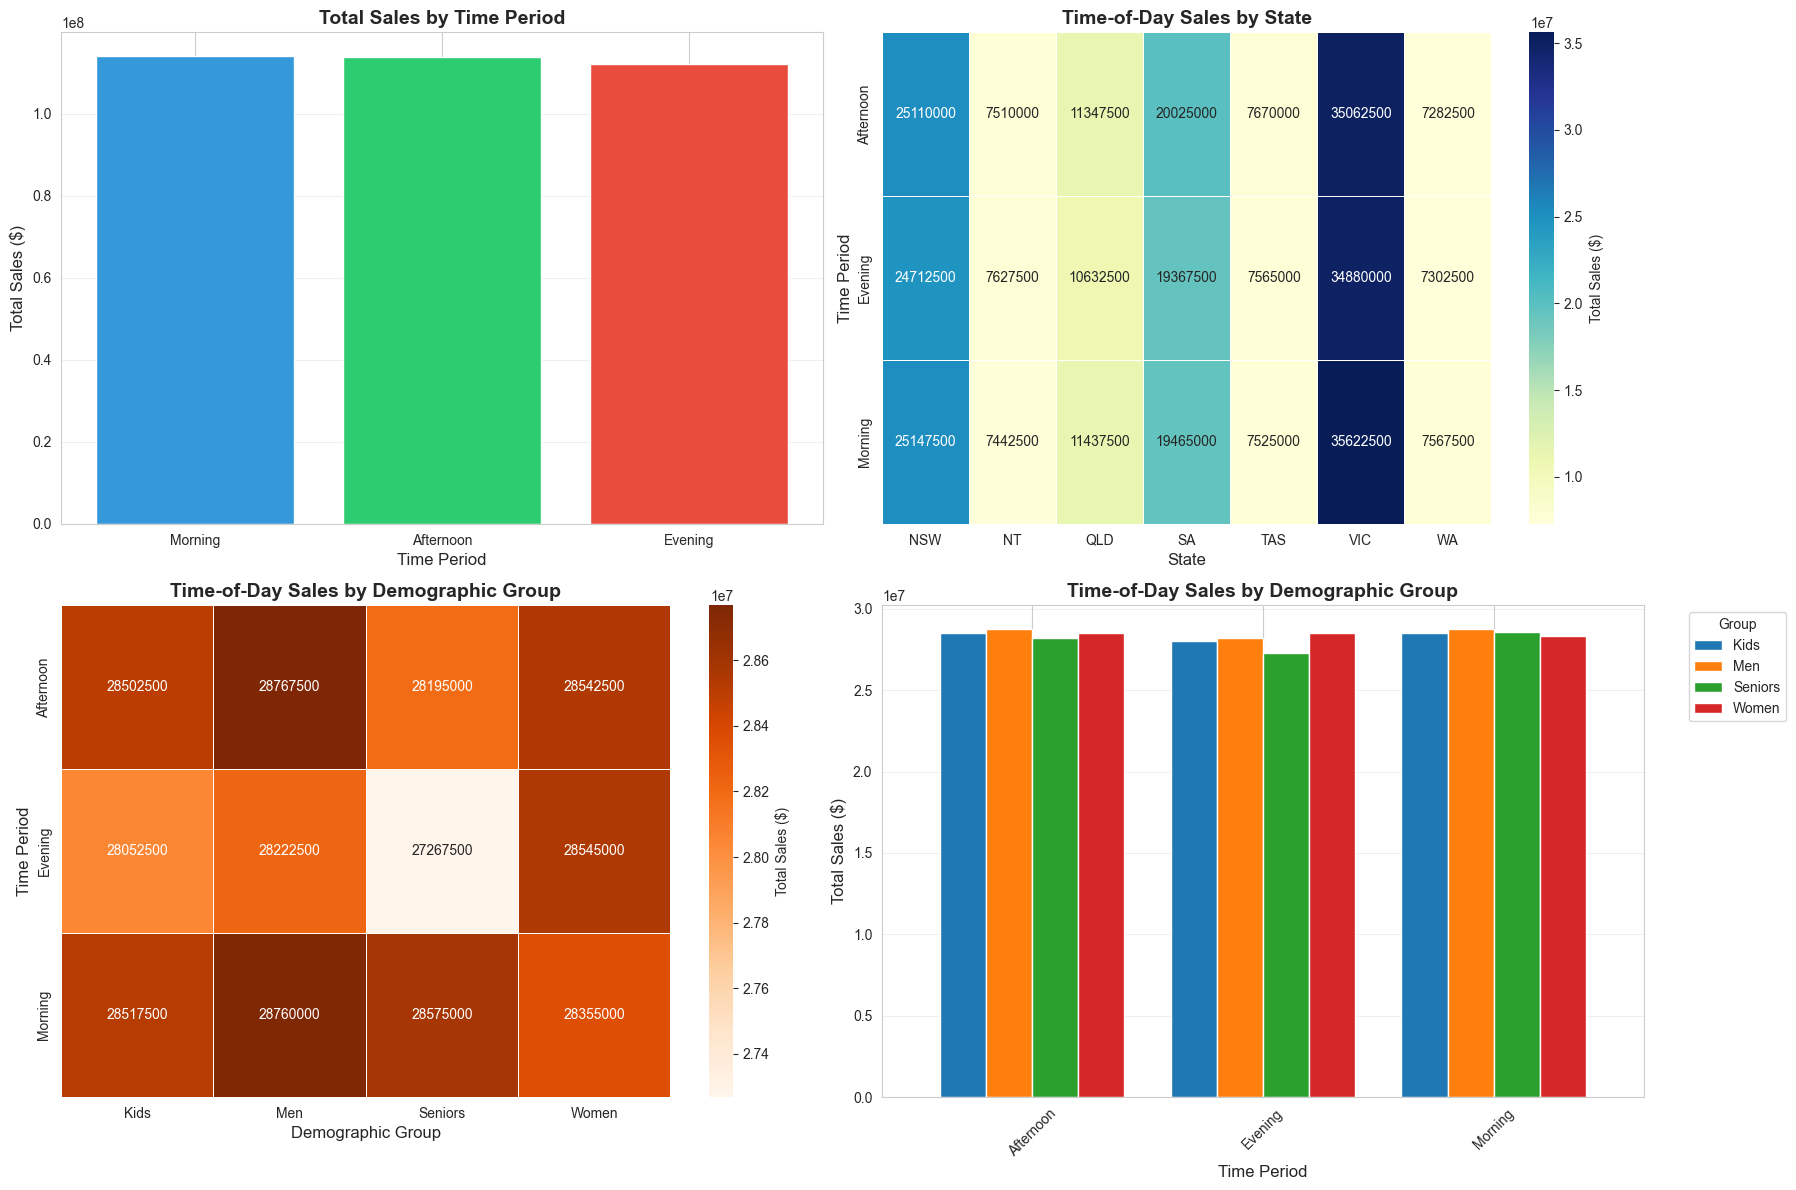

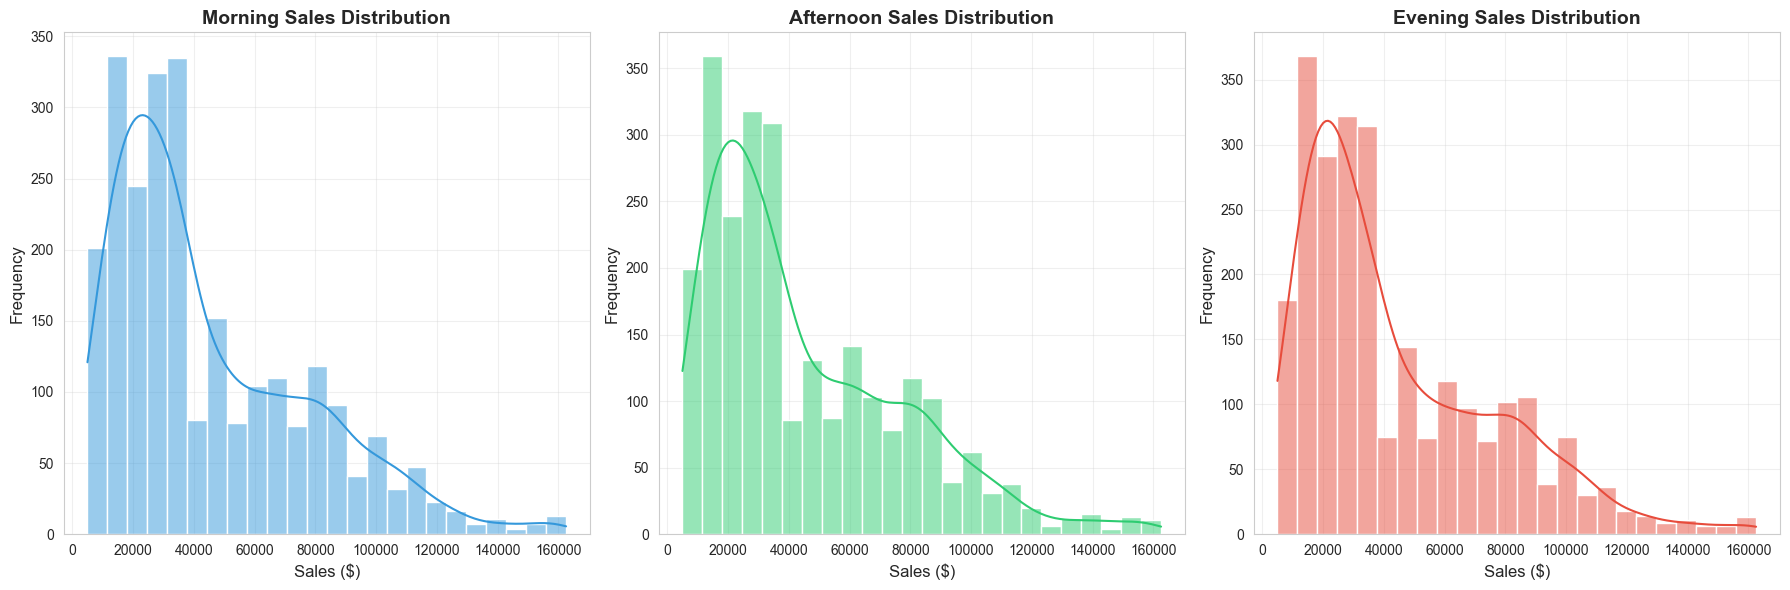

In [32]:
# Time-of-day analysis
print("=" * 60)
print("TIME-OF-DAY SALES ANALYSIS")
print("=" * 60)

# Sales by time period
time_analysis = df_clean.groupby('Time').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Unit': ['sum', 'mean']
}).round(2)
time_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Transaction_Count', 'Total_Units', 'Avg_Units']
time_analysis = time_analysis.sort_values('Total_Sales', ascending=False)

print("\nSales by Time Period:")
print(time_analysis)

# Identify peak and off-peak periods
peak_period = time_analysis.index[0]
off_peak_period = time_analysis.index[-1]

print("\n" + "=" * 60)
print("PEAK AND OFF-PEAK ANALYSIS")
print("=" * 60)
print(f"✓ PEAK PERIOD: {peak_period}")
print(f"  Total Sales: ${time_analysis.loc[peak_period, 'Total_Sales']:,.2f}")
print(f"  Average Sales: ${time_analysis.loc[peak_period, 'Avg_Sales']:,.2f}")
print(f"  Transactions: {int(time_analysis.loc[peak_period, 'Transaction_Count'])}")

print(f"\n✓ OFF-PEAK PERIOD: {off_peak_period}")
print(f"  Total Sales: ${time_analysis.loc[off_peak_period, 'Total_Sales']:,.2f}")
print(f"  Average Sales: ${time_analysis.loc[off_peak_period, 'Avg_Sales']:,.2f}")
print(f"  Transactions: {int(time_analysis.loc[off_peak_period, 'Transaction_Count'])}")

# Time analysis by state
print("\n" + "=" * 60)
print("TIME-OF-DAY ANALYSIS BY STATE")
print("=" * 60)
time_state_pivot = df_clean.pivot_table(values='Sales', index='Time', columns='State', aggfunc='sum')
print(time_state_pivot.round(2))

# Time analysis by group
print("\n" + "=" * 60)
print("TIME-OF-DAY ANALYSIS BY GROUP")
print("=" * 60)
time_group_pivot = df_clean.pivot_table(values='Sales', index='Time', columns='Group', aggfunc='sum')
print(time_group_pivot.round(2))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Overall time period sales
time_order = ['Morning', 'Afternoon', 'Evening']
time_sales = df_clean.groupby('Time')['Sales'].sum().reindex(time_order)
axes[0, 0].bar(time_sales.index, time_sales.values, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Total Sales by Time Period', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Time Period', fontsize=12)
axes[0, 0].set_ylabel('Total Sales ($)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Time period by state (heatmap)
sns.heatmap(time_state_pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5, 
            cbar_kws={'label': 'Total Sales ($)'}, ax=axes[0, 1])
axes[0, 1].set_title('Time-of-Day Sales by State', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('State', fontsize=12)
axes[0, 1].set_ylabel('Time Period', fontsize=12)

# 3. Time period by group (heatmap)
sns.heatmap(time_group_pivot, annot=True, fmt='.0f', cmap='Oranges', linewidths=0.5, 
            cbar_kws={'label': 'Total Sales ($)'}, ax=axes[1, 0])
axes[1, 0].set_title('Time-of-Day Sales by Demographic Group', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Demographic Group', fontsize=12)
axes[1, 0].set_ylabel('Time Period', fontsize=12)

# 4. Grouped bar chart: Time by Group
time_group_pivot.plot(kind='bar', ax=axes[1, 1], width=0.8)
axes[1, 1].set_title('Time-of-Day Sales by Demographic Group', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Time Period', fontsize=12)
axes[1, 1].set_ylabel('Total Sales ($)', fontsize=12)
axes[1, 1].legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Distribution plot using seaborn (as required)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, time_period in enumerate(['Morning', 'Afternoon', 'Evening']):
    time_data = df_clean[df_clean['Time'] == time_period]['Sales']
    sns.histplot(time_data, kde=True, ax=axes[idx], color=['#3498db', '#2ecc71', '#e74c3c'][idx])
    axes[idx].set_title(f'{time_period} Sales Distribution', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Sales ($)', fontsize=12)
    axes[idx].set_ylabel('Frequency', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 Comprehensive Dashboard: Daily, Weekly, Monthly, and Quarterly Views

**Explanation:**
A comprehensive dashboard provides multiple views of the same data:
- **Daily**: Day-to-day trends and patterns
- **Weekly**: Weekly performance cycles
- **Monthly**: Monthly comparisons (Oct, Nov, Dec)
- **Quarterly**: Overall Q4 summary

This multi-level view helps identify both short-term and long-term trends.

COMPREHENSIVE SALES DASHBOARD


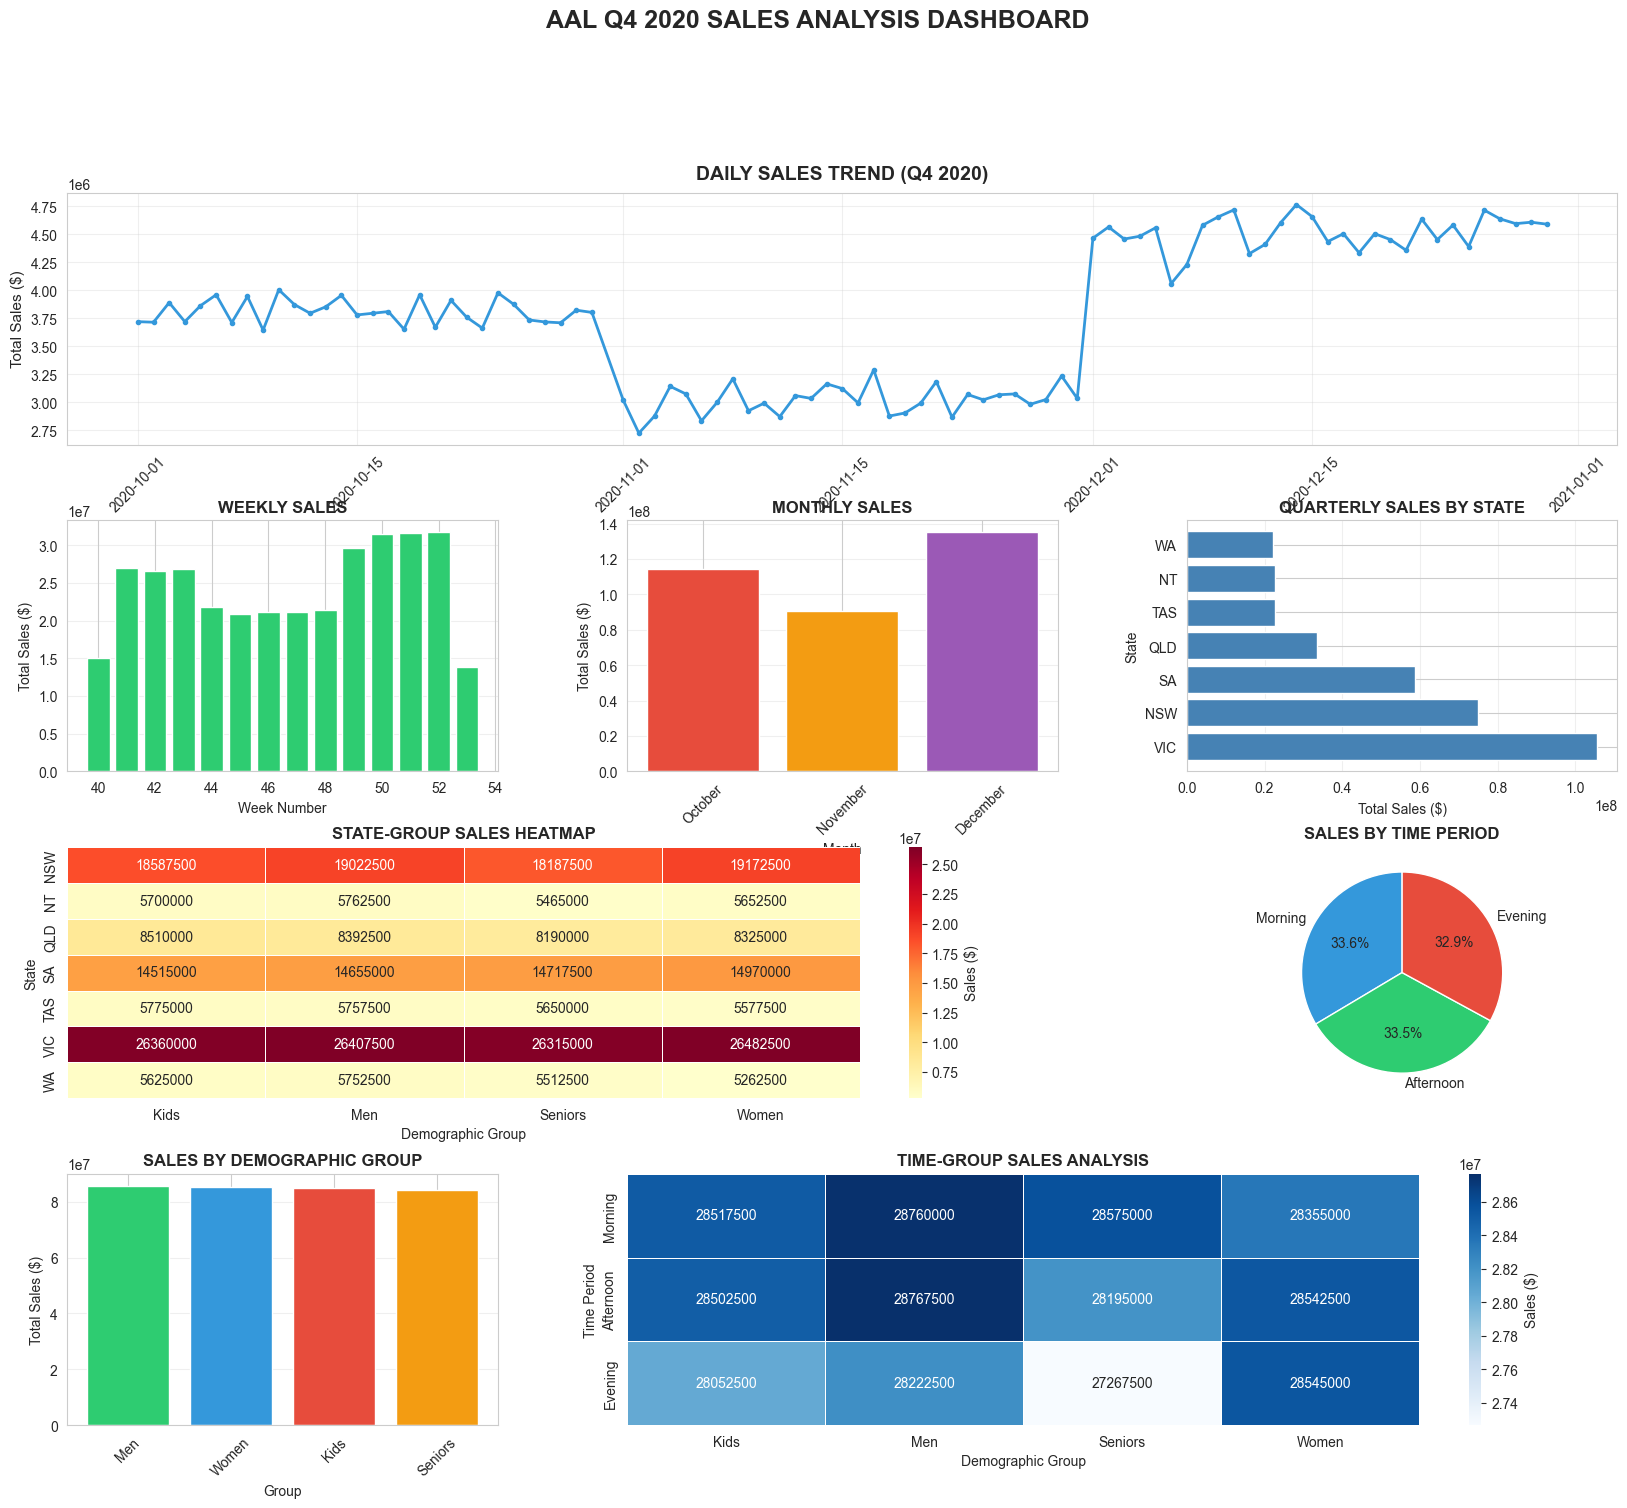


✓ Comprehensive dashboard created successfully!


In [33]:
# Comprehensive Dashboard
print("=" * 60)
print("COMPREHENSIVE SALES DASHBOARD")
print("=" * 60)

# Create a comprehensive dashboard figure
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# DAILY VIEW
ax1 = fig.add_subplot(gs[0, :])
daily_sales = df_clean.groupby('Date')['Sales'].sum()
ax1.plot(daily_sales.index, daily_sales.values, marker='o', linewidth=2, markersize=3, color='#3498db')
ax1.set_title('DAILY SALES TREND (Q4 2020)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Total Sales ($)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# WEEKLY VIEW
ax2 = fig.add_subplot(gs[1, 0])
weekly_sales = df_clean.groupby('Week')['Sales'].sum()
ax2.bar(weekly_sales.index, weekly_sales.values, color='#2ecc71')
ax2.set_title('WEEKLY SALES', fontsize=12, fontweight='bold')
ax2.set_xlabel('Week Number', fontsize=10)
ax2.set_ylabel('Total Sales ($)', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# MONTHLY VIEW
ax3 = fig.add_subplot(gs[1, 1])
monthly_sales = df_clean.groupby('Month_Name')['Sales'].sum()
month_order = ['October', 'November', 'December']
monthly_sales = monthly_sales.reindex(month_order)
ax3.bar(monthly_sales.index, monthly_sales.values, color=['#e74c3c', '#f39c12', '#9b59b6'])
ax3.set_title('MONTHLY SALES', fontsize=12, fontweight='bold')
ax3.set_xlabel('Month', fontsize=10)
ax3.set_ylabel('Total Sales ($)', fontsize=10)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# QUARTERLY STATE DISTRIBUTION
ax4 = fig.add_subplot(gs[1, 2])
state_sales_q = df_clean.groupby('State')['Sales'].sum().sort_values(ascending=False)
ax4.barh(state_sales_q.index, state_sales_q.values, color='steelblue')
ax4.set_title('QUARTERLY SALES BY STATE', fontsize=12, fontweight='bold')
ax4.set_xlabel('Total Sales ($)', fontsize=10)
ax4.set_ylabel('State', fontsize=10)
ax4.grid(True, alpha=0.3, axis='x')

# STATE-GROUP HEATMAP
ax5 = fig.add_subplot(gs[2, :2])
state_group_heatmap = df_clean.pivot_table(values='Sales', index='State', columns='Group', aggfunc='sum')
sns.heatmap(state_group_heatmap, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, 
            cbar_kws={'label': 'Sales ($)'}, ax=ax5)
ax5.set_title('STATE-GROUP SALES HEATMAP', fontsize=12, fontweight='bold')
ax5.set_xlabel('Demographic Group', fontsize=10)
ax5.set_ylabel('State', fontsize=10)

# TIME PERIOD ANALYSIS
ax6 = fig.add_subplot(gs[2, 2])
time_sales_q = df_clean.groupby('Time')['Sales'].sum()
time_order = ['Morning', 'Afternoon', 'Evening']
time_sales_q = time_sales_q.reindex(time_order)
ax6.pie(time_sales_q.values, labels=time_sales_q.index, autopct='%1.1f%%', 
        colors=['#3498db', '#2ecc71', '#e74c3c'], startangle=90)
ax6.set_title('SALES BY TIME PERIOD', fontsize=12, fontweight='bold')

# GROUP PERFORMANCE
ax7 = fig.add_subplot(gs[3, 0])
group_sales_q = df_clean.groupby('Group')['Sales'].sum().sort_values(ascending=False)
ax7.bar(group_sales_q.index, group_sales_q.values, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
ax7.set_title('SALES BY DEMOGRAPHIC GROUP', fontsize=12, fontweight='bold')
ax7.set_xlabel('Group', fontsize=10)
ax7.set_ylabel('Total Sales ($)', fontsize=10)
ax7.tick_params(axis='x', rotation=45)
ax7.grid(True, alpha=0.3, axis='y')

# TIME-GROUP ANALYSIS
ax8 = fig.add_subplot(gs[3, 1:])
time_group_heatmap = df_clean.pivot_table(values='Sales', index='Time', columns='Group', aggfunc='sum')
time_group_heatmap = time_group_heatmap.reindex(time_order)
sns.heatmap(time_group_heatmap, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5, 
            cbar_kws={'label': 'Sales ($)'}, ax=ax8)
ax8.set_title('TIME-GROUP SALES ANALYSIS', fontsize=12, fontweight='bold')
ax8.set_xlabel('Demographic Group', fontsize=10)
ax8.set_ylabel('Time Period', fontsize=10)

plt.suptitle('AAL Q4 2020 SALES ANALYSIS DASHBOARD', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Comprehensive dashboard created successfully!")

In [34]:
# Generate comprehensive insights and recommendations
print("=" * 80)
print("EXECUTIVE SUMMARY & RECOMMENDATIONS")
print("=" * 80)

# 1. State Analysis
print("\n" + "=" * 80)
print("1. STATE PERFORMANCE ANALYSIS")
print("=" * 80)
state_summary = df_clean.groupby('State')['Sales'].agg(['sum', 'mean']).sort_values('sum', ascending=False)
state_summary.columns = ['Total_Sales', 'Avg_Sales_per_Transaction']
print("\nState Rankings (by Total Sales):")
for idx, (state, row) in enumerate(state_summary.iterrows(), 1):
    print(f"{idx}. {state}: ${row['Total_Sales']:,.2f} (Avg: ${row['Avg_Sales_per_Transaction']:,.2f})")

highest_state = state_summary.index[0]
lowest_state = state_summary.index[-1]

print(f"\n✓ HIGHEST REVENUE STATE: {highest_state}")
print(f"  → Total Sales: ${state_summary.loc[highest_state, 'Total_Sales']:,.2f}")
print(f"  → Recommendation: Continue current strategies, consider expansion")

print(f"\n✓ LOWEST REVENUE STATE: {lowest_state}")
print(f"  → Total Sales: ${state_summary.loc[lowest_state, 'Total_Sales']:,.2f}")
print(f"  → Recommendation: Develop targeted sales programs, increase marketing")

# 2. Group Analysis
print("\n" + "=" * 80)
print("2. DEMOGRAPHIC GROUP PERFORMANCE")
print("=" * 80)
group_summary = df_clean.groupby('Group')['Sales'].agg(['sum', 'mean']).sort_values('sum', ascending=False)
group_summary.columns = ['Total_Sales', 'Avg_Sales_per_Transaction']
print("\nGroup Rankings (by Total Sales):")
for idx, (group, row) in enumerate(group_summary.iterrows(), 1):
    print(f"{idx}. {group}: ${row['Total_Sales']:,.2f} (Avg: ${row['Avg_Sales_per_Transaction']:,.2f})")

# 3. Time Analysis
print("\n" + "=" * 80)
print("3. TIME-OF-DAY PERFORMANCE")
print("=" * 80)
time_summary = df_clean.groupby('Time')['Sales'].agg(['sum', 'mean']).sort_values('sum', ascending=False)
time_summary.columns = ['Total_Sales', 'Avg_Sales_per_Transaction']
print("\nTime Period Rankings:")
for idx, (time, row) in enumerate(time_summary.iterrows(), 1):
    print(f"{idx}. {time}: ${row['Total_Sales']:,.2f} (Avg: ${row['Avg_Sales_per_Transaction']:,.2f})")

peak_time = time_summary.index[0]
off_peak_time = time_summary.index[-1]

print(f"\n✓ PEAK PERIOD: {peak_time}")
print(f"  → Recommendation: Allocate more resources, staff, and inventory")

print(f"\n✓ OFF-PEAK PERIOD: {off_peak_time}")
print(f"  → Recommendation: Launch promotional campaigns, Next Best Offers (NBO)")

# 4. Monthly Trends
print("\n" + "=" * 80)
print("4. MONTHLY TRENDS (Q4 2020)")
print("=" * 80)
monthly_summary = df_clean.groupby('Month_Name')['Sales'].sum()
month_order = ['October', 'November', 'December']
monthly_summary = monthly_summary.reindex(month_order)
print("\nMonthly Sales:")
for month, sales in monthly_summary.items():
    print(f"  {month}: ${sales:,.2f}")

# Calculate growth
if len(monthly_summary) >= 2:
    growth_rate = ((monthly_summary.iloc[-1] - monthly_summary.iloc[0]) / monthly_summary.iloc[0]) * 100
    print(f"\n  Growth Rate (Oct to Dec): {growth_rate:.2f}%")

# 5. Strategic Recommendations
print("\n" + "=" * 80)
print("5. STRATEGIC RECOMMENDATIONS FOR S&M DEPARTMENT")
print("=" * 80)
print("""
A. STATES WITH HIGHEST REVENUES:
   → Focus on maintaining market leadership
   → Consider expansion opportunities
   → Replicate successful strategies to other states

B. STATES WITH LOWER REVENUES:
   → Develop targeted sales programs
   → Increase marketing and promotional activities
   → Analyze successful state strategies for adaptation
   → Consider demographic-specific campaigns

C. PEAK PERIOD OPTIMIZATION:
   → Ensure adequate staffing during peak hours
   → Stock sufficient inventory
   → Maximize customer experience

D. OFF-PEAK PERIOD STRATEGIES:
   → Launch hyper-personalization campaigns
   → Implement Next Best Offer (NBO) programs
   → Offer time-specific promotions
   → Target specific demographic groups during off-peak

E. DEMOGRAPHIC TARGETING:
   → Focus on high-performing groups in each state
   → Develop group-specific marketing strategies
   → Create personalized offers based on group preferences

F. DATA-DRIVEN DECISIONS:
   → Continue monitoring daily, weekly, monthly trends
   → Set up automated reporting dashboards
   → Regular review of state and group performance
   → Adjust strategies based on quarterly reviews
""")

print("\n" + "=" * 80)
print("END OF EXECUTIVE SUMMARY")
print("=" * 80)

EXECUTIVE SUMMARY & RECOMMENDATIONS

1. STATE PERFORMANCE ANALYSIS

State Rankings (by Total Sales):
1. VIC: $105,565,000.00 (Avg: $97,745.37)
2. NSW: $74,970,000.00 (Avg: $69,416.67)
3. SA: $58,857,500.00 (Avg: $54,497.69)
4. QLD: $33,417,500.00 (Avg: $30,942.13)
5. TAS: $22,760,000.00 (Avg: $21,074.07)
6. NT: $22,580,000.00 (Avg: $20,907.41)
7. WA: $22,152,500.00 (Avg: $20,511.57)

✓ HIGHEST REVENUE STATE: VIC
  → Total Sales: $105,565,000.00
  → Recommendation: Continue current strategies, consider expansion

✓ LOWEST REVENUE STATE: WA
  → Total Sales: $22,152,500.00
  → Recommendation: Develop targeted sales programs, increase marketing

2. DEMOGRAPHIC GROUP PERFORMANCE

Group Rankings (by Total Sales):
1. Men: $85,750,000.00 (Avg: $45,370.37)
2. Women: $85,442,500.00 (Avg: $45,207.67)
3. Kids: $85,072,500.00 (Avg: $45,011.90)
4. Seniors: $84,037,500.00 (Avg: $44,464.29)

3. TIME-OF-DAY PERFORMANCE

Time Period Rankings:
1. Morning: $114,207,500.00 (Avg: $45,320.44)
2. Afternoon: $

## Conclusion

This comprehensive analysis provides:
1. ✅ Clean and normalized data ready for analysis
2. ✅ Descriptive statistics for Sales and Unit columns
3. ✅ Identification of highest/lowest performing states and groups
4. ✅ Weekly, monthly, and quarterly reports
5. ✅ Comprehensive dashboard with state-wise, group-wise, and time-of-day analysis
6. ✅ Strategic recommendations for data-driven decision making

**Next Steps:**
- Implement recommended sales programs for low-performing states
- Develop targeted marketing campaigns for off-peak periods
- Set up automated reporting for ongoing monitoring
- Review and adjust strategies quarterly based on new data

---

**Report Generated Using:**
- Python (Pandas, NumPy, SciPy)
- Data Visualization (Matplotlib, Seaborn)
- JupyterLab Notebook
- Statistical Analysis Methods

**Date:** Q4 2020 Sales Analysis
**Prepared for:** AAL Sales & Marketing Department